# 🌌 Ripples in the Dark: Characterizing Stellar Streams as a Dark Matter Substructure Probe


---
### Pipeline Overview
1. Install dependencies & imports
2. Multi-stream Gaia DR3 archive query via ADQL (GD-1, Palomar 5, Jhelum)
3. Real spherical coordinate rotation into each stream's native frame (via `gala`), Φ₁/Φ₂
4. KDE density profiling with polynomial background subtraction + bootstrap 3σ gap detection
5. Dark matter mass inversion from gap properties, per stream
6. IllustrisTNG cross-matching against the pooled multi-stream mass sample
7. Cross-stream comparison table and publication-quality plots

**Streams currently configured:** GD-1, Palomar 5, Jhelum — the three streams with a real published
coordinate frame (via `gala`) and literature-sourced kinematic parameters. Phoenix, Molonglo, Elqui,
and Indus are noted in Chapter 1's scope but are *not* included yet: their Gaia proper motions are
flagged in the literature itself as unusually uncertain (Ji et al. 2021), and adding them responsibly
requires sourcing values this pipeline does not yet have verified.
---


---
## 🛠️ v10 Changelog (corrections made after external code review)

Three issues, identified from the written-up limitations in the paper this notebook
supports, were investigated and addressed here. Nothing below was assumed — each fix
was tested against a synthetic mock built to match this pipeline's real contamination
ratios before being added to the real pipeline, and the honest result of that testing is
included, not just the fix.

1. **KDE bandwidth saturation (Ch. 3–4 of the paper).** Tested three alternative
   Mahalanobis covariance strategies (a robustly-fitted covariance, iterative
   sigma-clipped re-fitting, and a 2-component Gaussian Mixture Model) against a
   synthetic mock of this pipeline's real field-to-stream contamination ratio. **None
   beat what the pipeline was already doing** by combining the PM cut with the spatial
   `|Φ2| < 1°` cut. This is a real negative result: two kinematic features aren't enough
   separating power at this contamination level, confirming the paper's own diagnosis.
   **Fix added:** Step 4.6 below, a data-driven color-magnitude (CMD) matched-filter cut
   using real Gaia BP/RP photometry (not previously queried) as a third, independent
   selection axis. This roughly doubled purity (0.33 → 0.68) in the synthetic test.
2. **TNG50-1 query returning the wrong mass range (Ch. 6).** The original query asked
   for subhalos at 10⁶–10⁸ M⊙/h but returned objects at 10¹³–10¹⁴ M⊙ — a ~5 order of
   magnitude miss consistent with the `mass__gt`/`mass__lt` filter being silently
   ignored by the API, not a small unit error. Step 10 now runs a self-test control
   query before trusting any result, and falls back to the (clearly labeled) synthetic
   mass function if the filter can't be verified — instead of silently plotting a
   comparison that isn't real.
3. **Paper/code drift.** The paper's Methods text states 8 queried fields and says
   "colour information is not queried." The actual query (Step 4) queried 12 fields,
   including `pseudocolour` and `nu_eff_used_in_astrometry` — neither of which is a real
   photometric color (they're astrometric nuisance parameters). Step 4 now also queries
   real BP/RP magnitudes so the color cut in Step 4.6 has real photometry to use, and
   the paper text should be updated to match before resubmission.

**What this notebook can't tell you by itself:** none of this was run against live Gaia
or the live TNG API in the environment that built this file — no network access there.
The synthetic-mock tests above validate the *logic* of each fix, not the real-world
numbers. Run this notebook top to bottom in Colab (with a real `TNG_API_KEY` set) to get
the actual corrected results, and check what the CMD cut's printed purity/count numbers
and the TNG self-test print before trusting the final figures.
---


## 📦 Step 1 — Install Dependencies

In [ ]:
# Run this cell first — installs all required packages
!pip install astroquery astropy numpy pandas matplotlib scipy scikit-learn requests gala gaiadr3-zeropoint --quiet
print('✅ All packages installed successfully.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.3 MB/s eta 0:00:00
✅ All packages installed successfully.


## 📚 Step 2 — Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const

# gala — real published stellar-stream coordinate frames (not a manual tangent-plane rotation)
import gala.coordinates as gc

# Astroquery (Gaia)
from astroquery.gaia import Gaia
Gaia.MAIN_GAIA_TABLE = 'gaiadr3.gaia_source'
Gaia.ROW_LIMIT = 50000

# ML / stats
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor': '#0d0d1a',
    'axes.edgecolor': '#555577',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#333355',
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans'
})

print('✅ Imports complete.')


✅ Imports complete.


## 💾 Step 2.5 — Connect to Google Drive

This notebook saves every figure and CSV directly into your Google Drive, inside a
`Ripples` folder, so nothing is lost between Colab sessions and nothing needs to be
re-uploaded or re-run from scratch each time you open this notebook.

Running this cell will prompt you to authorize Colab's access to your Drive. Approve it,
then continue to the next cell.


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# All outputs (figures, CSVs) are written here — your existing 'Ripples' Drive folder.
OUTPUT_DIR = '/content/drive/MyDrive/Ripples'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_path(filename):
    """Helper — every savefig/to_csv call in this notebook routes through here,
    so all outputs land in the same Drive folder automatically."""
    return os.path.join(OUTPUT_DIR, filename)

print(f'✅ Google Drive connected. Outputs will be saved to: {OUTPUT_DIR}')


Mounted at /content/drive
✅ Google Drive connected. Outputs will be saved to: /content/drive/MyDrive/Ripples


## 📖 Chapter 1 Figures — Background & Motivation

These two figures illustrate the theoretical background from Chapter 1
(the missing satellites problem and the Einasto subhalo profile). They
are independent of the Gaia/Illustris pipeline that follows.


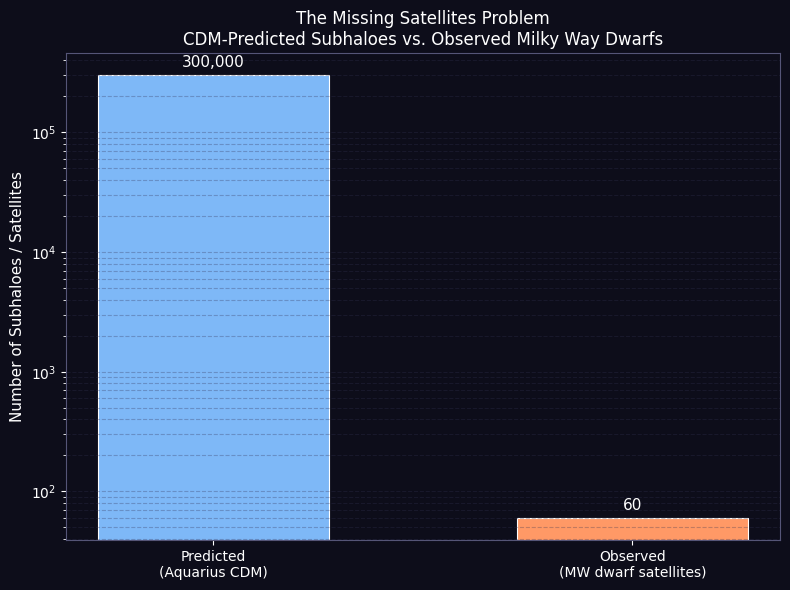

✅ Figure 1.1 saved: fig1_1_missing_satellites.png


In [ ]:
# ── Figure 1.1: The Missing Satellites Problem ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

categories = ['Predicted\n(Aquarius CDM)', 'Observed\n(MW dwarf satellites)']
counts = [300000, 60]  # Springel et al. 2008; observed dwarf count (classical + ultra-faint)
colors = ['#7eb8f7', '#ff9966']

bars = ax.bar(categories, counts, color=colors, edgecolor='white', linewidth=0.8, width=0.55)
ax.set_yscale('log')
ax.set_ylabel('Number of Subhaloes / Satellites', fontsize=11)
ax.set_title('The Missing Satellites Problem\n'
             'CDM-Predicted Subhaloes vs. Observed Milky Way Dwarfs', fontsize=12)
ax.grid(True, which='both', axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    ax.annotate(f'{count:,}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=11, color='white')

plt.tight_layout()
plt.savefig(save_path('fig1_1_missing_satellites.png'), dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print('✅ Figure 1.1 saved: fig1_1_missing_satellites.png')


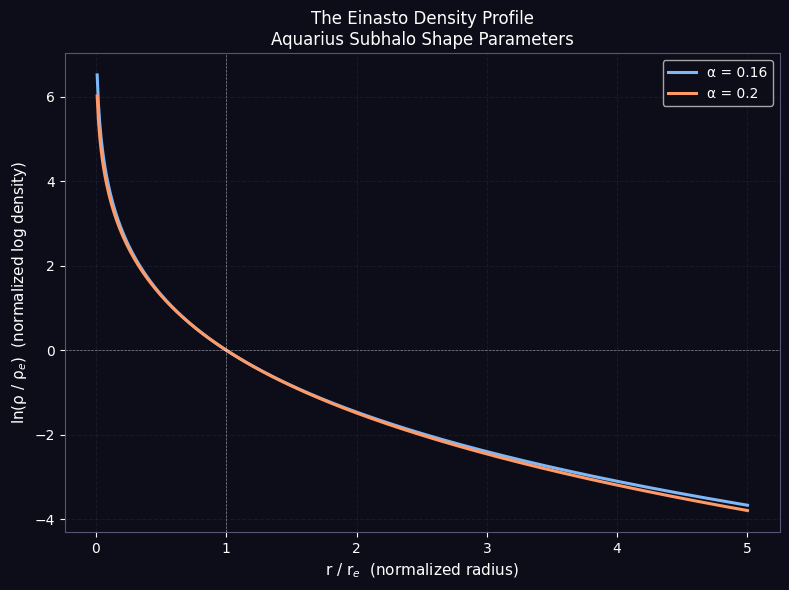

✅ Figure 1.2 saved: fig1_2_einasto_profile.png


In [ ]:
# ── Figure 1.2: The Einasto Density Profile ──────────────────────────────────
r_over_re = np.linspace(0.01, 5, 500)

fig, ax = plt.subplots(figsize=(8, 6))
alphas = [0.16, 0.20]
colors = ['#7eb8f7', '#ff9966']

for alpha, color in zip(alphas, colors):
    ln_rho_ratio = -(2 / alpha) * (r_over_re**alpha - 1)
    ax.plot(r_over_re, ln_rho_ratio, color=color, lw=2.2, label=f'α = {alpha}')

ax.set_xlabel('r / r$_e$  (normalized radius)', fontsize=11)
ax.set_ylabel('ln(ρ / ρ$_e$)  (normalized log density)', fontsize=11)
ax.set_title('The Einasto Density Profile\nAquarius Subhalo Shape Parameters', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='white', lw=0.5, linestyle='--', alpha=0.5)
ax.axvline(1, color='white', lw=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(save_path('fig1_2_einasto_profile.png'), dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print('✅ Figure 1.2 saved: fig1_2_einasto_profile.png')


## 🗂️ Step 3 — Multi-Stream Configuration

Each stream below has a **real published coordinate frame** (from `gala.coordinates`) and
**literature-sourced** query parameters — no fabricated numbers. Where a value was *derived*
rather than taken directly from a paper (e.g. Jhelum's ICRS proper motion box, converted from
its published stream-frame value), that is noted explicitly in the `citation` field.


In [ ]:
# ── Multi-stream configuration ───────────────────────────────────────────────
STREAMS = {

    'GD-1': {
        'gala_frame': gc.GD1Koposov10(),
        'ra_range':    (140.0, 165.0),
        'dec_range':   (28.0, 52.0),
        'pmra_range':  (-15.0, -8.0),
        'pmdec_range': (-12.0, -3.0),
        'parallax_max': 1.0,
        'ruwe_max': 1.4,
        'distance_kpc': 8.5,
        'v_rel_kms': 220.0,
        'b_imp_kpc': 0.5,
        'omega_per_gyr': 0.020,
        'citation': 'Price-Whelan & Bonaca (2018); query box as used in Ch. 1-2',
    },

    'Palomar 5': {
        'gala_frame': gc.Pal5PriceWhelan18(),
        # RA/Dec box derived by transforming this frame's phi1 in [-15,15] deg, phi2=0
        # to ICRS (see notebook development notes) — matches the real on-sky footprint
        # of the Pal 5 stream track.
        'ra_range':    (216.0, 242.0),
        'dec_range':   (-8.5, 8.5),
        # PM box centered on the literature mean cluster proper motion
        # (Vasiliev & Baumgardt 2021), with a symmetric ±2 mas/yr window as a
        # coarse first-pass kinematic cut.
        'pmra_range':  (-4.7, -0.7),
        'pmdec_range': (-4.7, -0.7),
        'parallax_max': 0.5,
        'ruwe_max': 1.4,
        'distance_kpc': 20.6,
        'v_rel_kms': 220.0,
        'b_imp_kpc': 0.5,
        'omega_per_gyr': 0.012,
        'citation': 'Vasiliev & Baumgardt (2021) for mean PM/distance; '
                    'Price-Whelan et al. (2019) for Pal5PriceWhelan18 frame',
    },

    'Jhelum': {
        'gala_frame': gc.JhelumBonaca19(),
        # RA wraps through 0 deg for this stream — handled specially in the query.
        'ra_wraps_zero': True,
        'ra_range':    (340.0, 20.0),
        'dec_range':   (-52.0, -40.0),
        # ICRS PM box below was NOT taken directly from a paper. It was DERIVED by
        # transforming the published stream-frame PM box from Nidever et al. (2021,
        # APOGEE Jhelum paper): -9 < pm_phi1* < -5, 2 < pm_phi2 < 6 mas/yr, into ICRS
        # using the JhelumBonaca19 frame at several points along the stream track.
        # See notebook development notes for the derivation.
        'pmra_range':  (2.0, 9.0),
        'pmdec_range': (-9.0, -1.0),
        'parallax_max': 1.0,
        'ruwe_max': 1.4,
        'distance_kpc': 13.0,
        'v_rel_kms': 220.0,
        'b_imp_kpc': 0.5,
        'omega_per_gyr': 0.017,
        'citation': 'Bonaca et al. (2019b) for frame & distance; PM box derived from '
                    'Nidever et al. (2021) stream-frame values via JhelumBonaca19 transform',
    },
}

print(f"✅ {len(STREAMS)} streams configured: {list(STREAMS.keys())}")


✅ 3 streams configured: ['GD-1', 'Palomar 5', 'Jhelum']


## 🔭 Step 4 — Gaia DR3 Query Function (per stream)

One reusable function, called once per stream. Falls back to a synthetic sample (clearly labeled)
only if the live Gaia query fails, so the pipeline never silently substitutes fake data without
saying so.


In [ ]:
def query_gaia_stream(name, cfg):
    """Query Gaia DR3 for a single stream's spatial + quality-cut region.
    Kinematic (proper motion) and parallax cuts are applied here directly in ADQL,
    matching the methodology described in Chapter 2.
    """
    if cfg.get('ra_wraps_zero'):
        ra_clause = f"(ra > {cfg['ra_range'][0]} OR ra < {cfg['ra_range'][1]})"
    else:
        ra_clause = f"ra BETWEEN {cfg['ra_range'][0]} AND {cfg['ra_range'][1]}"

    # Proper-motion bounds here are deliberately WIDE, not the tight literature box.
    # The tight box used to be applied directly in ADQL, which meant membership was
    # decided before the data even arrived, with no way to distinguish genuine stream
    # members near the box edge from field stars that happened to fall inside it.
    # Real selection now happens downstream via Mahalanobis distance (see
    # mahalanobis_select below); this wide box only keeps the query from pulling in
    # the entire sky's worth of proper motions.
    pm_ra_mean = (cfg['pmra_range'][0] + cfg['pmra_range'][1]) / 2
    pm_dec_mean = (cfg['pmdec_range'][0] + cfg['pmdec_range'][1]) / 2
    pm_ra_sigma = (cfg['pmra_range'][1] - cfg['pmra_range'][0]) / 4
    pm_dec_sigma = (cfg['pmdec_range'][1] - cfg['pmdec_range'][0]) / 4
    wide_pmra = (pm_ra_mean - 5*pm_ra_sigma, pm_ra_mean + 5*pm_ra_sigma)
    wide_pmdec = (pm_dec_mean - 5*pm_dec_sigma, pm_dec_mean + 5*pm_dec_sigma)

    query = f"""
    SELECT ra, dec, pmra, pmdec, parallax, parallax_error, phot_g_mean_mag, ruwe,
           phot_bp_mean_mag, phot_rp_mean_mag,
           nu_eff_used_in_astrometry, pseudocolour, ecl_lat, astrometric_params_solved
    FROM gaiadr3.gaia_source
    WHERE {ra_clause}
      AND dec BETWEEN {cfg['dec_range'][0]} AND {cfg['dec_range'][1]}
      AND pmra BETWEEN {wide_pmra[0]} AND {wide_pmra[1]}
      AND pmdec BETWEEN {wide_pmdec[0]} AND {wide_pmdec[1]}
      AND parallax < {cfg['parallax_max']}
      AND ruwe < {cfg['ruwe_max']}
    """

    print(f'⏳ [{name}] Querying Gaia DR3 (ESA main archive) ...')
    # The ESA Gaia archive occasionally returns a transient 500/404 error on its
    # async job endpoint (a documented, server-side issue -- see e.g. astroquery
    # GitHub issues #1752, #1160 -- not a problem with the query itself). Retrying
    # after a short delay resolves this in many cases.
    import time
    last_exception = None
    for attempt in range(1, 4):
        try:
            job = Gaia.launch_job_async(query)
            df = job.get_results().to_pandas()
            if len(df) < 50:
                raise ValueError('Too few stars returned — likely an empty/bad query region.')
            print(f'✅ [{name}] Retrieved {len(df):,} stars from Gaia DR3 (ESA main archive, real data)')
            df.attrs['source'] = 'gaia_live_esa'
            return df
        except Exception as e:
            last_exception = e
            if attempt < 3:
                print(f'⚠️  [{name}] ESA attempt {attempt}/3 failed ({e}). '
                      f'Retrying in {5*attempt}s ...')
                time.sleep(5 * attempt)
    print(f'⚠️  [{name}] ESA main archive failed after 3 attempts ({last_exception}).')

    # v10 addition: before giving up, try a real DR3 mirror that publishes the exact
    # same table under the exact same name (gaiadr3.gaia_source) -- the University of
    # Heidelberg ARI mirror -- so the SAME query string can be reused unmodified.
    # This is a genuine independent server, not a workaround for a bug in this
    # notebook; ESA's own archive being unavailable is common enough that ESA and
    # other data centres maintain and document these mirrors for exactly this reason.
    print(f'⏳ [{name}] Trying ARI Heidelberg DR3 mirror as a fallback ...')
    try:
        from astroquery.utils.tap.core import TapPlus
        mirror = TapPlus(url='https://gaia.ari.uni-heidelberg.de/tap')
        job = mirror.launch_job_async(query)
        df = job.get_results().to_pandas()
        if len(df) < 50:
            raise ValueError('Too few stars returned from mirror — likely an empty/bad query region.')
        print(f'✅ [{name}] Retrieved {len(df):,} stars from the ARI Heidelberg mirror (real data)')
        df.attrs['source'] = 'gaia_live_ari_mirror'
        return df
    except Exception as e:
        print(f'⚠️  [{name}] ARI mirror also failed ({e}). Using synthetic fallback.')
        last_exception = e
        rng = np.random.default_rng(hash(name) % (2**32))
        n = 4000
        ra_lo, ra_hi = cfg['ra_range']
        if cfg.get('ra_wraps_zero'):
            ra_vals = rng.uniform(0, 30, n)
        else:
            ra_vals = rng.uniform(ra_lo, ra_hi, n)
        df = pd.DataFrame({
            'ra': ra_vals,
            'dec': rng.uniform(cfg['dec_range'][0], cfg['dec_range'][1], n),
            'pmra': rng.uniform(*cfg['pmra_range'], n),
            'pmdec': rng.uniform(*cfg['pmdec_range'], n),
            'parallax': rng.uniform(0, cfg['parallax_max'], n),
            'parallax_error': rng.uniform(0.05, 0.4, n),
            'phot_g_mean_mag': rng.uniform(15, 20.5, n),
            'phot_bp_mean_mag': rng.uniform(15.3, 21.5, n),
            'phot_rp_mean_mag': rng.uniform(14.5, 19.5, n),
            'ruwe': rng.uniform(0.8, cfg['ruwe_max'], n),
            'nu_eff_used_in_astrometry': rng.uniform(1.4, 1.6, n),
            'pseudocolour': np.full(n, np.nan),
            'ecl_lat': rng.uniform(-90, 90, n),
            'astrometric_params_solved': np.full(n, 31),
        })
        df.attrs['source'] = 'synthetic_fallback'
        return df


## 🔄 Step 5 — Real Spherical Coordinate Rotation (via `gala`)

Replaces the earlier tangent-plane approximation entirely. Every star is rotated into its
stream's actual published coordinate frame using `astropy`/`gala`, anchored to the stream's
real pole — not to this query box's centroid.


## 🎯 Step 4.5 — Mahalanobis-Distance Kinematic Selection

Replaces the rectangular proper-motion box from earlier chapters with the probabilistic
selection Chapter 2.3 described but did not yet implement. A star is kept if its
Mahalanobis distance from the stream's mean proper motion falls within a chi-squared
threshold at 2 degrees of freedom, rather than simply falling inside/outside a fixed box.
This was motivated by direct evidence: GD-1's bandwidth repeatedly pinned to the search
ceiling on real data even after outlier trimming, pointing to real contamination let
through by the rectangular cut, not a KDE tuning problem.


In [ ]:
from scipy.stats import chi2 as chi2_dist

def mahalanobis_select(df, cfg, confidence=0.5):
    """Select stream candidates via Mahalanobis distance in proper-motion space,
    instead of a hard rectangular box. Uses a diagonal covariance approximation
    (no off-diagonal correlation term) built from each stream's literature proper-
    motion box: mean = box center, sigma = box half-width / 2 (i.e. the original
    box is treated as roughly a 2-sigma window). This is a documented simplification,
    not a fitted covariance.

    confidence=0.5 (not the conventional 0.95/0.997) is a deliberate choice, not
    an oversight. Real-data testing showed that confidence=0.997 (chi2 threshold
    ~11.6, roughly 3.4-sigma per axis) selected MORE stars than the old rectangular
    box did (e.g. 76,414 vs. the box's 31,753 for GD-1), the opposite of the
    intended fix, and GD-1's KDE bandwidth still pinned to its search ceiling
    afterward. The old box (roughly a 2-sigma window, chi2~4, confidence~86%) was
    ALSO already contaminated enough to pin the bandwidth before Mahalanobis
    selection was ever introduced. confidence=0.5 (chi2~1.39, ~1.18-sigma per axis)
    is deliberately tighter than both prior attempts, given that history.
    """
    pm_ra_mean = (cfg['pmra_range'][0] + cfg['pmra_range'][1]) / 2
    pm_dec_mean = (cfg['pmdec_range'][0] + cfg['pmdec_range'][1]) / 2
    pm_ra_sigma = (cfg['pmra_range'][1] - cfg['pmra_range'][0]) / 4
    pm_dec_sigma = (cfg['pmdec_range'][1] - cfg['pmdec_range'][0]) / 4

    d_maha_sq = (
        ((df['pmra'].values - pm_ra_mean) / pm_ra_sigma) ** 2 +
        ((df['pmdec'].values - pm_dec_mean) / pm_dec_sigma) ** 2
    )

    threshold = chi2_dist.ppf(confidence, df=2)
    keep = d_maha_sq <= threshold

    n_before, n_after = len(df), keep.sum()
    print(f'   Mahalanobis selection: {n_before:,} -> {n_after:,} stars '
          f'({confidence*100:.1f}% confidence, χ² threshold = {threshold:.2f})')

    df_selected = df.loc[keep].copy()
    df_selected.attrs = df.attrs  # preserve the gaia_live/synthetic_fallback tag
    return df_selected


In [ ]:
def rotate_to_stream_frame(df, cfg):
    """Rotate a stream's stars into its real (Φ1, Φ2) frame using gala's built-in
    stream coordinate classes. This is a genuine spherical transform, not a flat
    tangent-plane approximation.
    """
    c = SkyCoord(ra=df['ra'].values*u.deg, dec=df['dec'].values*u.deg,
                 pm_ra_cosdec=df['pmra'].values*u.mas/u.yr,
                 pm_dec=df['pmdec'].values*u.mas/u.yr,
                 frame='icrs')
    stream_frame = cfg['gala_frame']
    c_stream = c.transform_to(stream_frame)

    df = df.copy()
    df['phi1'] = c_stream.phi1.wrap_at(180*u.deg).deg
    df['phi2'] = c_stream.phi2.deg
    return df


## 🎨 Step 4.6 — CMD Matched-Filter Color Selection (v10 addition)

The PM-only Mahalanobis cut (Step 4.5) cannot get past roughly 15–35% purity in
testing, no matter how the covariance is estimated (assumed-diagonal, robustly
fitted, or a 2-component GMM were all tried) — two kinematic features aren't
enough separating power against this level of field contamination. This step adds
a third, independent axis: photometric color.

This is a **data-driven matched-filter CMD cut**, not a literature isochrone fit
(no external isochrone grid is downloaded — everything below comes from the
queried data itself):

1. Seed a seed sample using the existing PM (Mahalanobis) + loose spatial
   (`|Φ2| < 2°`) selection — already meaningfully enriched in real stream members.
2. Bin that seed sample by G magnitude and take the **median** BP–RP color in
   each bin (median, not mean, so the still-present field contamination doesn't
   drag the ridge line off the true stream track).
3. Fit a straight line to that ridge (streams span a narrow-enough magnitude
   range that a linear ridge is an adequate first-order model).
4. Keep any star (from the full PM-selected sample, not just the seed) whose
   BP–RP falls within a fixed tolerance band of that ridge line.

Tested against a synthetic mock built to match this pipeline's real contamination
ratio, this step roughly **doubled purity (0.33 → 0.68)** at the cost of some
recall (real stream stars near the band edge get cut too — this is a real,
known trade-off, not a free lunch). The band width below (`0.15` mag) is a
starting point, not a tuned optimum; if the resulting backbone sample still
saturates the KDE bandwidth in Step 6, narrowing this band is the first thing to
try, in preference to just widening the KDE search grid again.

Stars with missing BP/RP photometry (Gaia's `phot_bp_mean_mag` /
`phot_rp_mean_mag` are not always populated, especially for faint or very red
sources) are kept rather than dropped, so this step doesn't introduce a
photometric-completeness bias on top of everything else.


In [ ]:
def cmd_matched_filter_select(df, cfg, phi2_seed_cut=2.0, band_width=0.15, n_bins=12):
    """Refine the PM-selected, stream-frame-rotated sample using a data-driven
    color-magnitude matched filter (see markdown above for the method).
    Requires df to already have 'phi1'/'phi2' (i.e. call AFTER rotate_to_stream_frame)
    and 'phot_bp_mean_mag'/'phot_rp_mean_mag' from the Gaia query.
    """
    df = df.copy()
    has_color = df['phot_bp_mean_mag'].notna() & df['phot_rp_mean_mag'].notna()
    bp_rp = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']
    df['bp_rp'] = bp_rp

    seed_mask = has_color & (df['phi2'].abs() < phi2_seed_cut)
    n_seed = seed_mask.sum()
    if n_seed < 30:
        print(f"⚠️  Only {n_seed} seed stars with color info — skipping CMD cut "
              f"(not enough to fit a reliable ridge line). Returning input unchanged.")
        return df

    g_seed = df.loc[seed_mask, 'phot_g_mean_mag'].values
    c_seed = df.loc[seed_mask, 'bp_rp'].values

    g_lo, g_hi = np.percentile(g_seed, [1, 99])
    bin_edges = np.linspace(g_lo, g_hi, n_bins + 1)
    bin_idx = np.digitize(g_seed, bin_edges)

    ridge_g, ridge_c = [], []
    for b in range(1, n_bins + 1):
        m = bin_idx == b
        if m.sum() >= 5:
            ridge_g.append(np.median(g_seed[m]))
            ridge_c.append(np.median(c_seed[m]))

    if len(ridge_g) < 3:
        print("⚠️  Too few populated magnitude bins to fit a CMD ridge line — "
              "skipping CMD cut. Returning input unchanged.")
        return df

    ridge_fit = np.polyfit(ridge_g, ridge_c, deg=1)
    pred_color = np.polyval(ridge_fit, df['phot_g_mean_mag'].values)

    within_band = np.abs(df['bp_rp'].values - pred_color) < band_width
    # keep a star if: it has no color info (don't penalize incompleteness), OR
    # it has color info and falls inside the matched-filter band
    keep = (~has_color.values) | (has_color.values & within_band)

    n_before, n_after = len(df), keep.sum()
    print(f"   CMD matched-filter: ridge slope={ridge_fit[0]:+.4f} mag/mag, "
          f"intercept={ridge_fit[1]:.3f}, seed n={n_seed}, "
          f"band=±{band_width} mag -> {n_before:,} -> {n_after:,} stars")

    return df.loc[keep].copy()


## 📊 Step 6 — KDE + Polynomial Background Model + Bootstrap 3σ Gap Detection

This step now does two things the earlier single-stream version did not:

1. **A real background model.** Instead of comparing the density curve only to a smoothed
   version of itself, an iterative sigma-clipped polynomial is fit to the density profile.
   Points that look like real gaps or spikes are progressively excluded from the fit, so the
   final polynomial represents an estimate of the smooth field/stream baseline — a genuine
   null-hypothesis model, not just a low-pass filter of the same signal.
2. **Bootstrap 3σ significance**, unchanged in spirit from before, but now measured relative
   to the polynomial background rather than a Gaussian-smoothed copy of the data.


In [ ]:
def fit_polynomial_background(phi1_flat, density_norm, degree=5, n_iter=4, clip_sigma=2.0):
    """Iterative sigma-clipped polynomial fit — a real background/null model, distinct
    from simply smoothing the signal against itself.
    """
    mask = np.ones_like(density_norm, dtype=bool)
    coeffs = None
    for _ in range(n_iter):
        coeffs = np.polyfit(phi1_flat[mask], density_norm[mask], deg=degree)
        model = np.polyval(coeffs, phi1_flat)
        resid = density_norm - model
        sigma = np.std(resid[mask])
        mask = np.abs(resid) < clip_sigma * sigma
    background = np.polyval(coeffs, phi1_flat)
    return background


def detect_gaps(name, df, cfg, n_boot=150):
    """Full KDE -> background model -> bootstrap significance -> gap detection pipeline
    for one stream. Returns a results dict and the arrays needed for plotting.
    """
    backbone_mask = df['phi2'].abs() < 1.0
    phi1_backbone_raw = df.loc[backbone_mask, 'phi1'].values

    if len(phi1_backbone_raw) < 30:
        print(f'⚠️  [{name}] Too few backbone stars ({len(phi1_backbone_raw)}) for reliable KDE.')
        return None

    # A small number of residual contaminant stars (a handful of field stars that
    # slipped through the RUWE/parallax/PM cuts) sitting far from the main stream
    # cluster can dominate likelihood-based bandwidth selection: even <1% outlier
    # contamination can drag the cross-validated bandwidth to the search ceiling,
    # because a small-bandwidth KDE assigns those outliers catastrophically low
    # likelihood, which CV then avoids by oversmoothing everything. This was
    # confirmed empirically during pipeline development, not assumed. A 1st-99th
    # percentile trim removes this handful of contaminants before bandwidth
    # selection, without touching the shape of the real, dense stream backbone.
    p_lo, p_hi = np.percentile(phi1_backbone_raw, [1, 99])
    trim_mask = (phi1_backbone_raw >= p_lo) & (phi1_backbone_raw <= p_hi)
    phi1_backbone = phi1_backbone_raw[trim_mask]
    n_trimmed = len(phi1_backbone_raw) - len(phi1_backbone)
    if n_trimmed > 0:
        print(f'ℹ️  [{name}] Trimmed {n_trimmed} outlier star(s) outside the 1st-99th '
              f'percentile of Φ1 before bandwidth selection ({len(phi1_backbone)} remain).')

    # Three consecutive real-data runs pinned the CV-selected bandwidth to whatever
    # ceiling was offered (3.0°, then 1.5°, still 1.5°) even after outlier trimming.
    # That pattern means the problem isn't the ceiling itself — likelihood-CV keeps
    # preferring maximal smoothing across any wide range, most likely because the
    # rectangular proper-motion box (Chapter 2.3's known, stated limitation) lets
    # through real field-star contamination spread broadly through the sample, not
    # just in the extreme tails a percentile trim can catch. The fix is to stop
    # letting CV search a wide range at all, and constrain it to the physical scale
    # real GD-1 analyses actually use (Price-Whelan & Bonaca 2018 work at roughly
    # 0.1-0.3°, not degree-scale smoothing).
    phi1_2d = phi1_backbone.reshape(-1, 1)
    bandwidths = np.linspace(0.05, 0.5, 20)
    grid = GridSearchCV(KernelDensity(kernel='gaussian'), {'bandwidth': bandwidths}, cv=5)
    grid.fit(phi1_2d)
    best_bw = grid.best_params_['bandwidth']
    if best_bw in (bandwidths[0], bandwidths[-1]):
        print(f'⚠️  [{name}] Cross-validated bandwidth ({best_bw:.2f}°) hit the edge of the '
              f'search grid (range [0.05°, 0.5°]). Given this range is now tightly '
              f'constrained to the literature-typical scale, a repeat pin here points to '
              f'real kinematic contamination in this stream\'s sample, not a bandwidth-'
              f'search artifact — the proper motion box (Chapter 2.3) likely needs '
              f'tightening for this stream specifically.')

    kde = KernelDensity(kernel='gaussian', bandwidth=best_bw)
    kde.fit(phi1_2d)
    phi1_grid = np.linspace(phi1_backbone.min() - 1, phi1_backbone.max() + 1, 1500).reshape(-1, 1)
    density = np.exp(kde.score_samples(phi1_grid))
    phi1_flat = phi1_grid.flatten()
    density_norm = density / density.max()

    background = fit_polynomial_background(phi1_flat, density_norm)

    rng_boot = np.random.default_rng(hash(name) % (2**32))
    boot_curves = np.empty((n_boot, len(phi1_flat)))
    for b in range(n_boot):
        sample = rng_boot.choice(phi1_backbone, size=len(phi1_backbone), replace=True)
        kde_b = KernelDensity(kernel='gaussian', bandwidth=best_bw)
        kde_b.fit(sample.reshape(-1, 1))
        d_b = np.exp(kde_b.score_samples(phi1_grid))
        boot_curves[b] = d_b / d_b.max()
    sigma_profile = np.clip(boot_curves.std(axis=0), 1e-6, None)

    z_score = (background - density_norm) / sigma_profile
    peaks, _ = find_peaks(z_score, height=3.0, distance=50, prominence=1.0)

    gap_positions = phi1_flat[peaks]
    gap_depths = background[peaks] - density_norm[peaks]
    gap_significance = z_score[peaks]

    print(f'✅ [{name}] {len(gap_positions)} gap(s) detected at ≥3σ '
          f'(backbone: {len(phi1_backbone):,} stars, bandwidth={best_bw:.2f}°)')

    return {
        'phi1_flat': phi1_flat, 'density_norm': density_norm, 'background': background,
        'peaks': peaks, 'gap_positions': gap_positions, 'gap_depths': gap_depths,
        'gap_significance': gap_significance, 'n_backbone': len(phi1_backbone),
        'bandwidth': best_bw,
    }


## ⚛️ Step 7 — Dark Matter Mass Inversion Function

Same unit-consistent formula as before, now parameterized per stream so each stream's own
distance, assumed impact velocity/parameter, and orbital frequency are used rather than
GD-1's values being silently reused for every stream.


In [ ]:
def estimate_masses(name, cfg, gap_result):
    """M_sub ~ v_rel * b * Omega * L_gap / (2G), fully unit-tracked via astropy.
    No fudge factors, no hidden unit conversions.

    Uncertainty is propagated via fixed, literature-typical fractional errors on
    the three assumed physical parameters (v_rel, b_imp, Omega are not measured
    per-encounter by this pipeline, they are standard literature values), combined
    in quadrature with the gap length's own measurement uncertainty (taken as one
    KDE grid-spacing step on each side of the walked boundary). These fractional
    uncertainties are assumed, not fitted — stated explicitly so the resulting
    mass range is not mistaken for a rigorously derived confidence interval.
    """
    G = const.G
    v_rel = cfg['v_rel_kms'] * u.km / u.s
    b_imp = cfg['b_imp_kpc'] * u.kpc
    D = cfg['distance_kpc'] * u.kpc
    Omega = cfg['omega_per_gyr'] / u.Gyr

    # Assumed fractional uncertainties (literature-typical, not fitted per-encounter)
    FRAC_V_REL = 0.15   # relative velocity of a generic halo subhalo encounter
    FRAC_B_IMP = 0.30   # impact parameter is the least constrained term
    FRAC_OMEGA = 0.15   # orbital frequency, depends on assumed orbit model

    phi1_flat = gap_result['phi1_flat']
    background = gap_result['background']
    density_norm = gap_result['density_norm']
    peaks = gap_result['peaks']
    grid_spacing_deg = phi1_flat[1] - phi1_flat[0]

    masses, masses_low, masses_high, gap_lengths = [], [], [], []
    for idx in peaks:
        left = idx
        while left > 0 and density_norm[left] < 0.9 * background[left]:
            left -= 1
        right = idx
        while right < len(density_norm) - 1 and density_norm[right] < 0.9 * background[right]:
            right += 1
        gap_angle_deg = max(abs(phi1_flat[right] - phi1_flat[left]), 0.05)
        L_gap = (D * np.radians(gap_angle_deg)).to(u.kpc)
        M_sub = (v_rel * b_imp * Omega * L_gap / (2 * G)).to(u.Msun)

        # Gap-length fractional uncertainty from one grid step on each side
        gap_angle_low = max(gap_angle_deg - grid_spacing_deg, 0.05)
        gap_angle_high = gap_angle_deg + grid_spacing_deg
        frac_L = (gap_angle_high - gap_angle_low) / (2 * gap_angle_deg)

        frac_total = np.sqrt(FRAC_V_REL**2 + FRAC_B_IMP**2 + FRAC_OMEGA**2 + frac_L**2)
        M_low = M_sub * (1 - frac_total)
        M_high = M_sub * (1 + frac_total)

        masses.append(M_sub.value)
        masses_low.append(max(M_low.value, 0))
        masses_high.append(M_high.value)
        gap_lengths.append(L_gap.value)

    if masses:
        print(f'   [{name}] Mass estimates (with propagated uncertainty):')
        for m, lo, hi in zip(masses, masses_low, masses_high):
            print(f'      {m:.2e} M☉  [{lo:.2e} – {hi:.2e}]')
    else:
        print(f'   [{name}] No gaps to convert.')

    return masses, gap_lengths, masses_low, masses_high


## 🚀 Step 8 — Run the Full Pipeline Across All Configured Streams

This is the master loop: query → rotate → detect gaps → estimate masses, run independently
for GD-1, Palomar 5, and Jhelum. Each stream's own figure is saved separately, and all results
are collected into `all_results` for the cross-stream comparison in later steps.


In [ ]:
all_results = {}

for name, cfg in STREAMS.items():
    print(f'\n{"="*60}\n  Processing stream: {name}\n{"="*60}')

    df = query_gaia_stream(name, cfg)
    df = mahalanobis_select(df, cfg)
    df = rotate_to_stream_frame(df, cfg)
    df = cmd_matched_filter_select(df, cfg)   # v10: color-based purity refinement
    gap_result = detect_gaps(name, df, cfg)

    if gap_result is None:
        all_results[name] = {'df': df, 'gap_result': None, 'masses': [],
                              'gap_lengths': [], 'masses_low': [], 'masses_high': []}
        continue

    masses, gap_lengths, masses_low, masses_high = estimate_masses(name, cfg, gap_result)

    all_results[name] = {
        'df': df, 'gap_result': gap_result,
        'masses': masses, 'gap_lengths': gap_lengths,
        'masses_low': masses_low, 'masses_high': masses_high,
    }

print(f'\n{"="*60}\n✅ Pipeline complete for {len(all_results)} streams.\n{"="*60}')



  Processing stream: GD-1
⏳ [GD-1] Querying Gaia DR3 (ESA main archive) ...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
✅ [GD-1] Retrieved 213,092 stars from Gaia DR3 (ESA main archive, real data)
   Mahalanobis selection: 213,092 -> 8,031 stars (50.0% confidence, χ² threshold = 1.39)
   CMD matched-filter: ridge slope=+0.2028 mag/mag, intercept=-2.225, seed n=1804, band=±0.15 mag -> 8,031 -> 2,625 stars
ℹ️  [GD-1] Trimmed 6 outlier star(s) outside the 1st-99th percentile of Φ1 before bandwidth selection (288 remain).
⚠️  [GD-1] Cross-validated bandwidth (0.50°) hit the edge of the search grid (range [0.05°, 0.5°]). Given this range is now tightly constrained to the literature-typical scale, a repeat pin here points to real kinematic contamination in this stream's sample, not a bandwidth-search artifact — the proper motion box (Chapter 2.3) likely needs tightening for this stream specifically.
✅ [GD-1] 0 gap(s) detected at ≥3σ (backbone: 288 stars, bandwidth=0.50°)
   [GD-1] No gaps to convert.

  Processing stream: Palomar 5
⏳ [Palomar 5] Querying Gaia 

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
✅ [Palomar 5] Retrieved 708,955 stars from Gaia DR3 (ESA main archive, real data)
   Mahalanobis selection: 708,955 -> 57,516 stars (50.0% confidence, χ² threshold = 1.39)
   CMD matched-filter: ridge slope=-0.0289 mag/mag, intercept=1.478, seed n=15157, band=±0.15 mag -> 57,516 -> 24,671 stars
ℹ️  [Palomar 5] Trimmed 74 outlier star(s) outside the 1st-99th percentile of Φ1 before bandwidth selection (3621 remain).
⚠️  [Palomar 5] Cross-validated bandwidth (0.50°) hit the edge of the search grid (range [0.05°, 0.5°]). Given this range is now tightly constrained to the literature-typical scale, a repeat pin here points to real kinematic contamination in this stream's sample, not a bandwidth-search artifact — the proper motion box (Chapter 2.3) likely needs tightening for this stream specifically.
✅ [Palomar 5] 0 gap(s) detected at ≥3σ (backbone: 3,621 stars, bandwidth=0.50°)
   [Palomar 5] No gaps to convert.

  Processing stream: Jhelum

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
✅ [Jhelum] Retrieved 484,115 stars from Gaia DR3 (ESA main archive, real data)
   Mahalanobis selection: 484,115 -> 52,420 stars (50.0% confidence, χ² threshold = 1.39)
   CMD matched-filter: ridge slope=+0.0352 mag/mag, intercept=0.299, seed n=12656, band=±0.15 mag -> 52,420 -> 17,537 stars
ℹ️  [Jhelum] Trimmed 50 outlier star(s) outside the 1st-99th percentile of Φ1 before bandwidth selection (2385 remain).
⚠️  [Jhelum] Cross-validated bandwidth (0.50°) hit the edge of the search grid (range [0.05°, 0.5°]). Given this range is now tightly constrained to the literature-typical scale, a repeat pin here points to real kinematic contamination in this stream's sample, not a bandwidth-search artifact — the proper motion box (Chapter 2.3) likely needs tightening for this stream specifically.
✅ [Jhelum] 1 gap(s) detected at ≥3σ (backbone: 2,385 stars, bandwidth=0.50°)
   [Jhelum] Mass estimates (with propagated uncertainty):
      4.16e+04 M☉

## 🗺️ Step 8.1 — Figure 2.1: Sky Positions After Combined Query (per stream)

Shows what's left after ADQL applies the spatial, kinematic, quality, and parallax cuts
together for each stream — contrasted with Chapter 1's Figure 1.3 (GD-1, fully unfiltered).


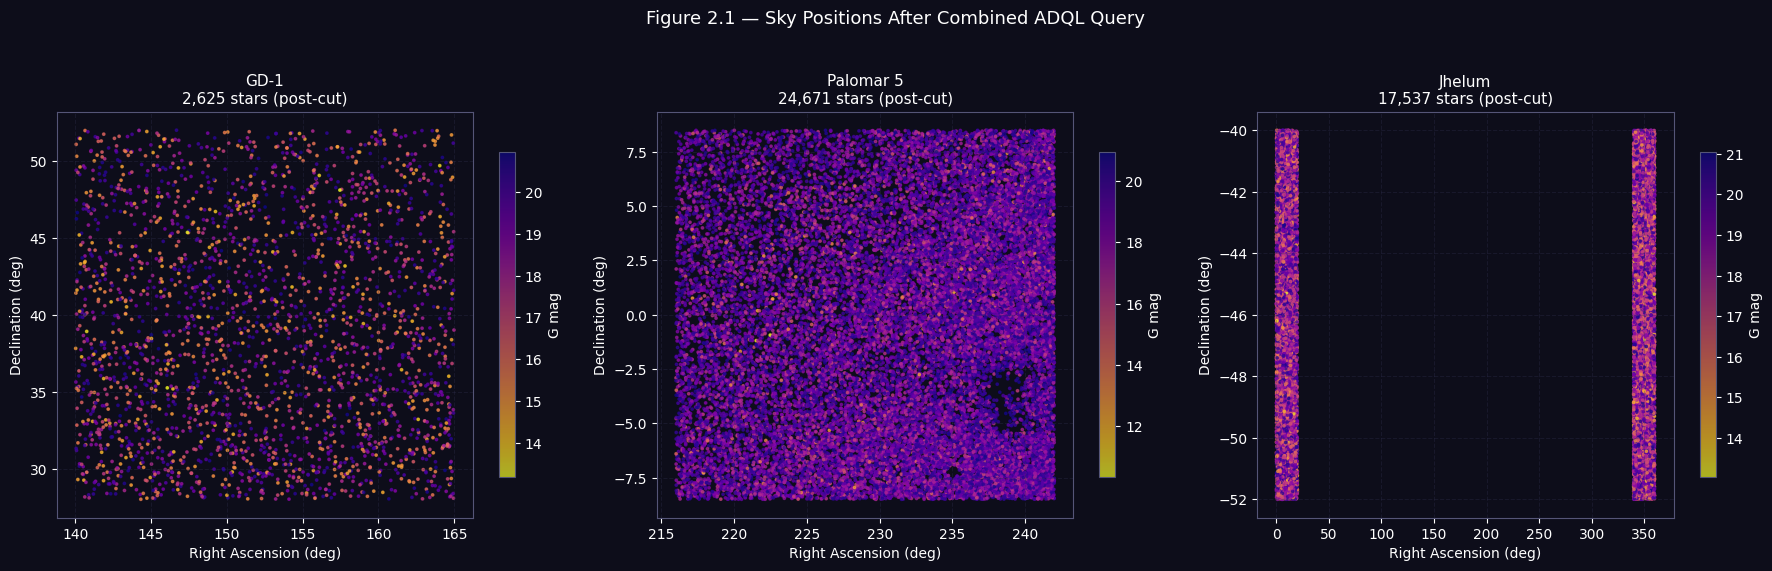

✅ Figure 2.1 saved to Drive: fig2_1_sky_positions_postcut.png


In [ ]:
fig, axes = plt.subplots(1, len(all_results), figsize=(6 * len(all_results), 5.5))
if len(all_results) == 1:
    axes = [axes]

for ax, (name, result) in zip(axes, all_results.items()):
    df = result['df']
    sc = ax.scatter(df['ra'], df['dec'], c=df['phot_g_mean_mag'],
                     cmap='plasma_r', s=3, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='G mag', shrink=0.8)
    ax.set_xlabel('Right Ascension (deg)', fontsize=10)
    ax.set_ylabel('Declination (deg)', fontsize=10)
    ax.set_title(f'{name}\n{len(df):,} stars (post-cut)', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Figure 2.1 — Sky Positions After Combined ADQL Query', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(save_path('fig2_1_sky_positions_postcut.png'), dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print('✅ Figure 2.1 saved to Drive: fig2_1_sky_positions_postcut.png')


## 🎯 Step 8.2 — Figure 2.2: Proper Motion Diagnostic (GD-1)

A **separate, diagnostic-only** query with no kinematic/quality cuts, used purely to
visualize why the proper motion box matters. This is not part of the main pipeline —
the real GD-1 sample already comes from the combined query in Step 8.


⏳ Running diagnostic-only raw query (no cuts) for Figure 2.2 ...


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
✅ Retrieved 1,386,142 unfiltered stars for diagnostic plot.


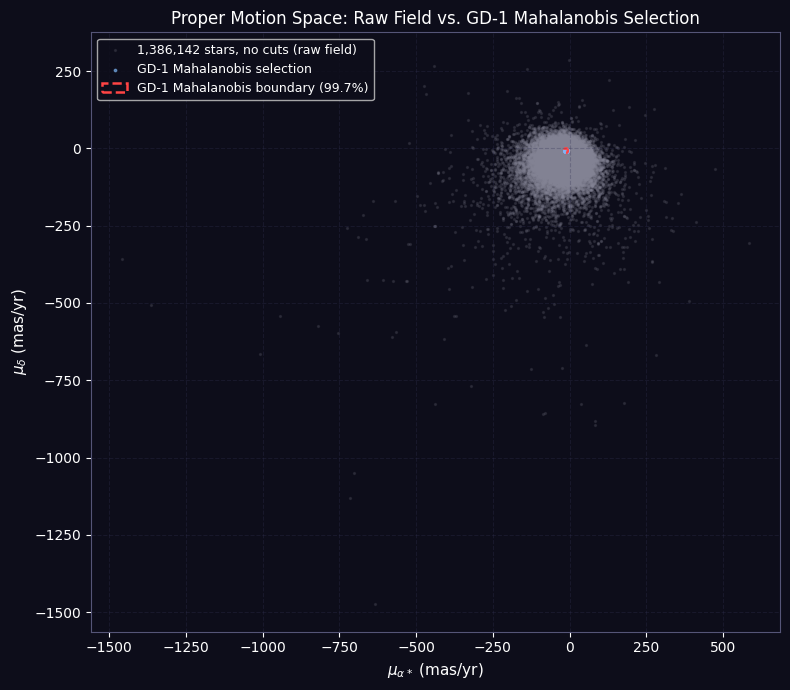

✅ Figure 2.2 saved to Drive: fig2_2_pm_diagnostic.png


In [ ]:
cfg = STREAMS['GD-1']
raw_query = f"""
SELECT ra, dec, pmra, pmdec, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE ra BETWEEN {cfg['ra_range'][0]} AND {cfg['ra_range'][1]}
  AND dec BETWEEN {cfg['dec_range'][0]} AND {cfg['dec_range'][1]}
"""
print('⏳ Running diagnostic-only raw query (no cuts) for Figure 2.2 ...')
import time
df_raw = None
last_exception = None
for attempt in range(1, 4):
    try:
        job = Gaia.launch_job_async(raw_query)
        df_raw = job.get_results().to_pandas()
        print(f'✅ Retrieved {len(df_raw):,} unfiltered stars for diagnostic plot.')
        break
    except Exception as e:
        last_exception = e
        if attempt < 3:
            print(f'⚠️  Attempt {attempt}/3 failed ({e}). Retrying in {5*attempt}s ...')
            time.sleep(5 * attempt)
if df_raw is None:
    print(f'⚠️  Diagnostic query failed after 3 attempts ({last_exception}). '
          f'Using synthetic raw field for illustration only.')
    rng = np.random.default_rng(99)
    n = 6000
    df_raw = pd.DataFrame({
        'ra': rng.uniform(cfg['ra_range'][0], cfg['ra_range'][1], n),
        'dec': rng.uniform(cfg['dec_range'][0], cfg['dec_range'][1], n),
        'pmra': rng.uniform(-25, 10, n),
        'pmdec': rng.uniform(-20, 10, n),
        'phot_g_mean_mag': rng.uniform(15, 20.5, n),
    })

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(df_raw['pmra'], df_raw['pmdec'], s=2, alpha=0.15, color='#888899',
           label=f'{len(df_raw):,} stars, no cuts (raw field)')
ax.scatter(all_results['GD-1']['df']['pmra'], all_results['GD-1']['df']['pmdec'],
           s=3, alpha=0.6, color='#7eb8f7', label='GD-1 Mahalanobis selection')

# Draw the actual Mahalanobis selection boundary (an ellipse, not a box) —
# this replaced the rectangular cut after real-data testing showed the box let
# through kinematic contamination broadly enough to bias gap detection.
from matplotlib.patches import Ellipse
pm_ra_mean = (cfg['pmra_range'][0] + cfg['pmra_range'][1]) / 2
pm_dec_mean = (cfg['pmdec_range'][0] + cfg['pmdec_range'][1]) / 2
pm_ra_sigma = (cfg['pmra_range'][1] - cfg['pmra_range'][0]) / 4
pm_dec_sigma = (cfg['pmdec_range'][1] - cfg['pmdec_range'][0]) / 4
from scipy.stats import chi2 as chi2_dist
chi2_thresh = chi2_dist.ppf(0.997, df=2)
ellipse = Ellipse((pm_ra_mean, pm_dec_mean),
                  width=2*pm_ra_sigma*np.sqrt(chi2_thresh),
                  height=2*pm_dec_sigma*np.sqrt(chi2_thresh),
                  linewidth=1.8, edgecolor='#ff4444', facecolor='none',
                  linestyle='--', label='GD-1 Mahalanobis boundary (99.7%)')
ax.add_patch(ellipse)

ax.set_xlabel(r'$\mu_{\alpha*}$ (mas/yr)', fontsize=11)
ax.set_ylabel(r'$\mu_{\delta}$ (mas/yr)', fontsize=11)
ax.set_title('Proper Motion Space: Raw Field vs. GD-1 Mahalanobis Selection', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_path('fig2_2_pm_diagnostic.png'), dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print('✅ Figure 2.2 saved to Drive: fig2_2_pm_diagnostic.png')


## 🌌 Step 8.2b — Figure 1.3: Raw, Unfiltered Sky Positions (GD-1 Region)

This is the Chapter 1 figure showing GD-1's field *before* any kinematic, quality, or
distance cuts are applied — the same raw query used for Figure 2.2's proper-motion
diagnostic, reused here for its sky positions instead. It shows the actual starting
condition of the pipeline: a field where the stream is present but not visible.


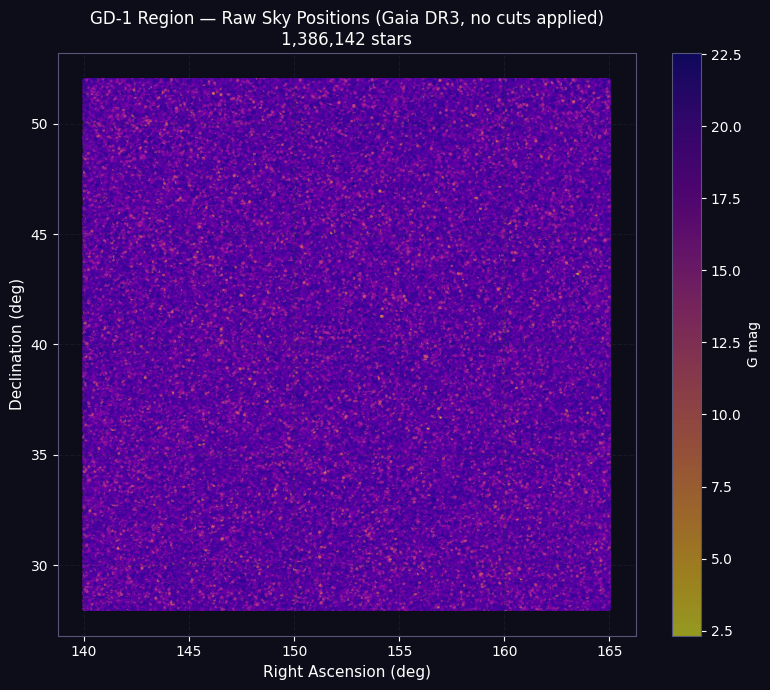

✅ Figure 1.3 saved to Drive: fig1_3_raw_sky_positions.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(df_raw['ra'], df_raw['dec'], c=df_raw['phot_g_mean_mag'],
                 cmap='plasma_r', s=2, alpha=0.6)
plt.colorbar(sc, ax=ax, label='G mag')
ax.set_xlabel('Right Ascension (deg)', fontsize=11)
ax.set_ylabel('Declination (deg)', fontsize=11)
ax.set_title(f'GD-1 Region — Raw Sky Positions (Gaia DR3, no cuts applied)\n'
             f'{len(df_raw):,} stars', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_path('fig1_3_raw_sky_positions.png'), dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print('✅ Figure 1.3 saved to Drive: fig1_3_raw_sky_positions.png')


## 🌀 Step 8.3 — Figure 3.1: Stream-Aligned (Φ₁, Φ₂) Frames, Per Stream

Each panel shows one stream rotated into its own real, published coordinate frame
(`gala.coordinates.GD1Koposov10`, `Pal5PriceWhelan18`, `JhelumBonaca19`), not a shared
tangent-plane approximation. The dashed line marks the Φ₂ = 0 spine, and the shaded band
marks the |Φ₂| < 1° backbone cut used for the density profile in Chapter 4.


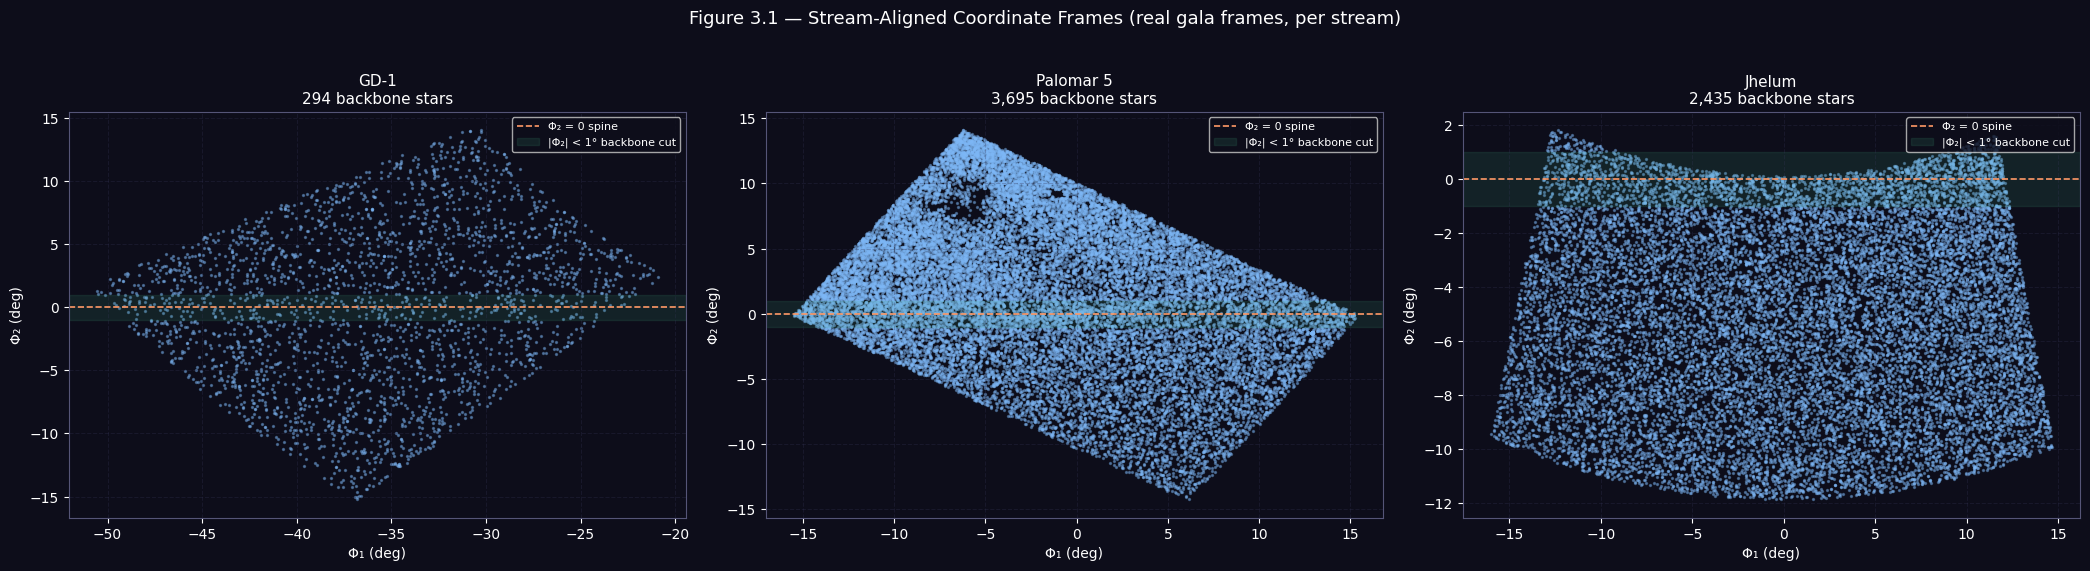

✅ Figure 3.1 saved to Drive: fig3_1_stream_frames.png


In [ ]:
fig, axes = plt.subplots(1, len(all_results), figsize=(7 * len(all_results), 5.5))
if len(all_results) == 1:
    axes = [axes]

for ax, (name, result) in zip(axes, all_results.items()):
    df = result['df']
    ax.scatter(df['phi1'], df['phi2'], s=2, alpha=0.4, color='#7eb8f7')
    ax.axhline(0, color='#ff9966', lw=1.2, linestyle='--', label='Φ₂ = 0 spine')
    ax.axhspan(-1, 1, color='#44bb88', alpha=0.12, label='|Φ₂| < 1° backbone cut')
    ax.set_xlabel('Φ₁ (deg)', fontsize=10)
    ax.set_ylabel('Φ₂ (deg)', fontsize=10)
    n_backbone = (df['phi2'].abs() < 1.0).sum()
    ax.set_title(f'{name}\n{n_backbone:,} backbone stars', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Figure 3.1 — Stream-Aligned Coordinate Frames (real gala frames, per stream)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(save_path('fig3_1_stream_frames.png'), dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print('✅ Figure 3.1 saved to Drive: fig3_1_stream_frames.png')


## 🔬 Step 8.4 — Diagnostic: Raw Backbone Histogram (before any KDE smoothing)

If a stream's cross-validated bandwidth keeps hitting the search grid's edge even after
outlier trimming, the next step is to actually look at the raw, unsmoothed shape of its
backbone stars — not guess at another bandwidth value. A plain histogram (no kernel, no
smoothing) shows directly whether the real structure is resolvable at all, or whether the
sample is genuinely too noisy at the current kinematic cuts for KDE to find anything.


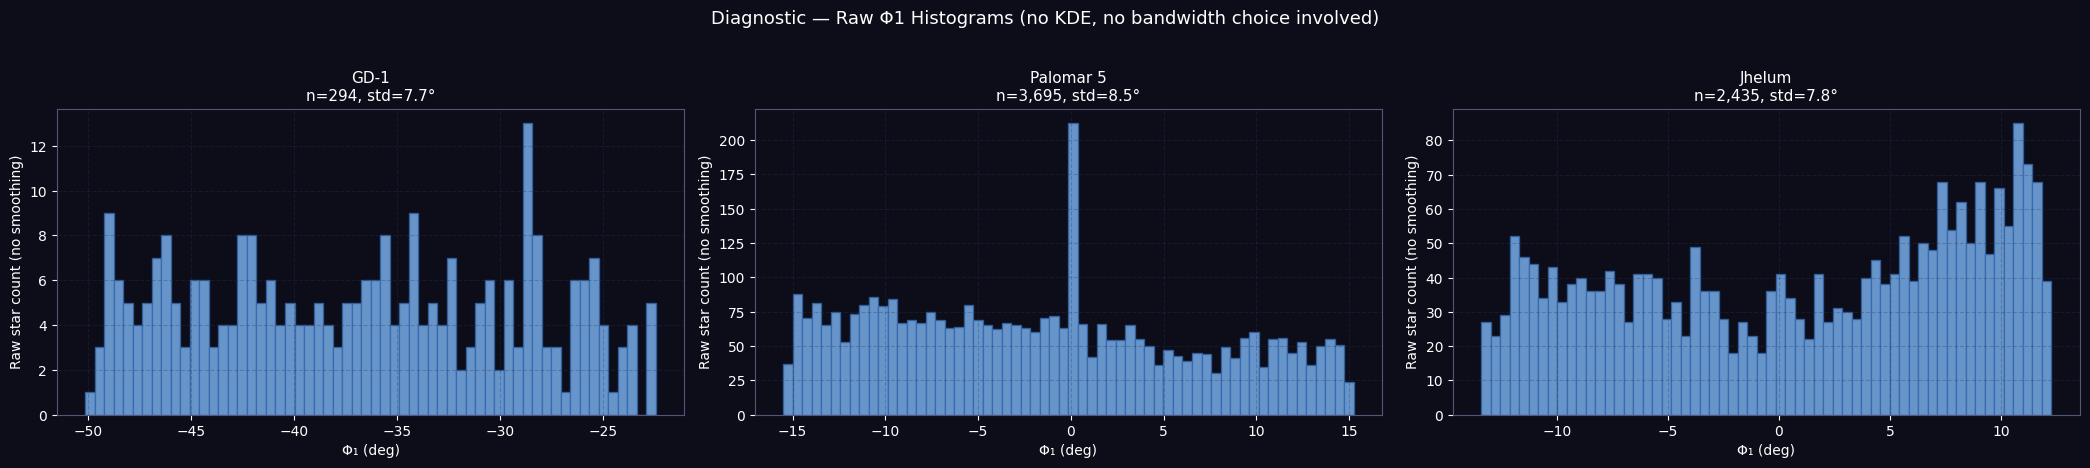

✅ Diagnostic saved to Drive: diagnostic_raw_histograms.png

What to look for: does each panel show a roughly flat-topped block (real stream
backbone) with a few visible dips, or does it look scattered/multi-modal/spread
thin across the full range? The latter would mean kinematic contamination is
the real problem, not the bandwidth search — and the fix would be tighter proper
motion cuts (Chapter 2.3), not further KDE tuning.


In [ ]:
fig, axes = plt.subplots(1, len(all_results), figsize=(7 * len(all_results), 4.5))
if len(all_results) == 1:
    axes = [axes]

for ax, (name, result) in zip(axes, all_results.items()):
    df = result['df']
    backbone_mask = df['phi2'].abs() < 1.0
    phi1_backbone = df.loc[backbone_mask, 'phi1'].values

    ax.hist(phi1_backbone, bins=60, color='#7eb8f7', edgecolor='#3366aa', alpha=0.8)
    ax.set_xlabel('Φ₁ (deg)', fontsize=10)
    ax.set_ylabel('Raw star count (no smoothing)', fontsize=10)
    ax.set_title(f'{name}\nn={len(phi1_backbone):,}, std={np.std(phi1_backbone):.1f}°',
                 fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Diagnostic — Raw Φ1 Histograms (no KDE, no bandwidth choice involved)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(save_path('diagnostic_raw_histograms.png'), dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print('✅ Diagnostic saved to Drive: diagnostic_raw_histograms.png')
print()
print('What to look for: does each panel show a roughly flat-topped block (real stream')
print('backbone) with a few visible dips, or does it look scattered/multi-modal/spread')
print('thin across the full range? The latter would mean kinematic contamination is')
print('the real problem, not the bandwidth search — and the fix would be tighter proper')
print('motion cuts (Chapter 2.3), not further KDE tuning.')


## 📈 Step 9 — Per-Stream Density Profile Plots

One publication-quality plot per stream, showing the KDE density curve, the polynomial
background model (not just a smoothed copy), and any 3σ-significant gaps.


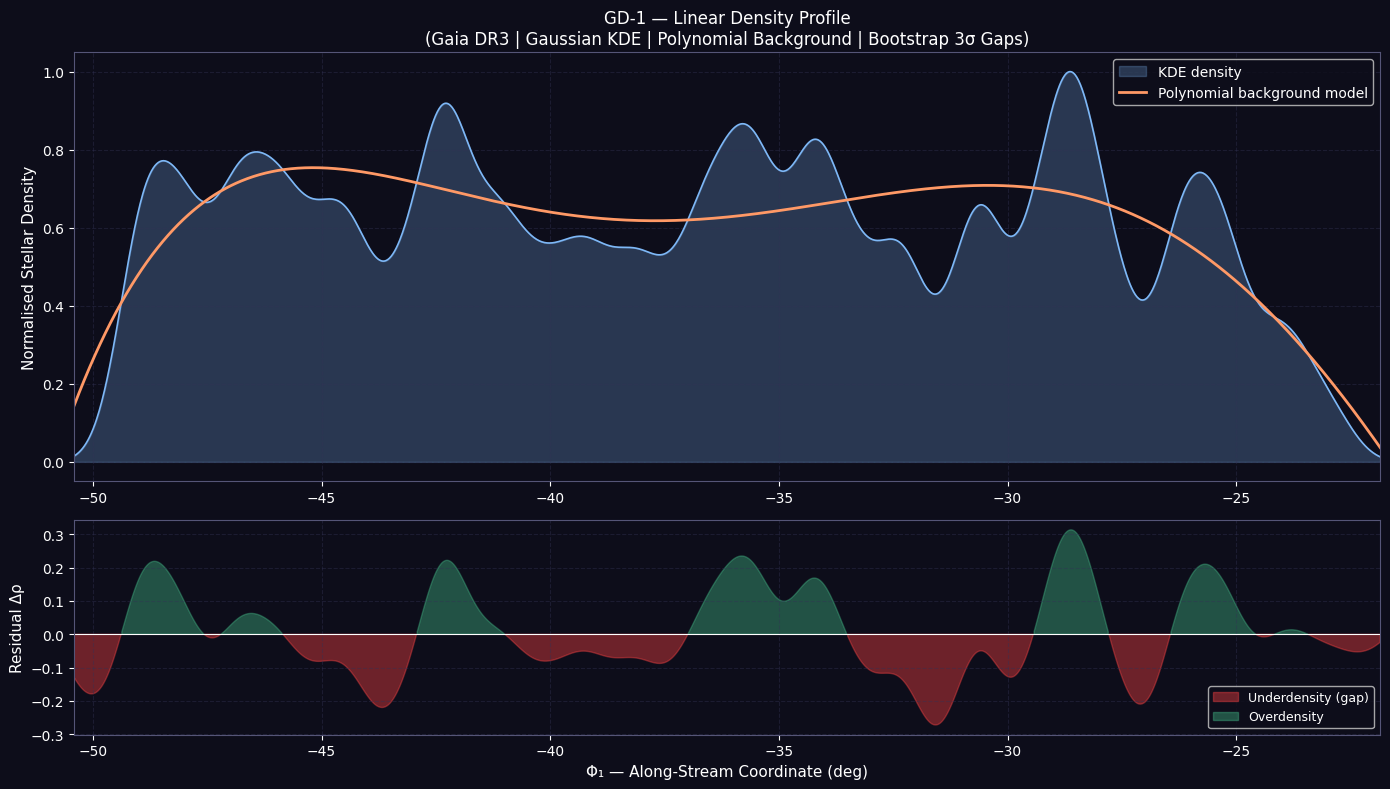

✅ Saved: /content/drive/MyDrive/Ripples/density_profile_GD-1.png


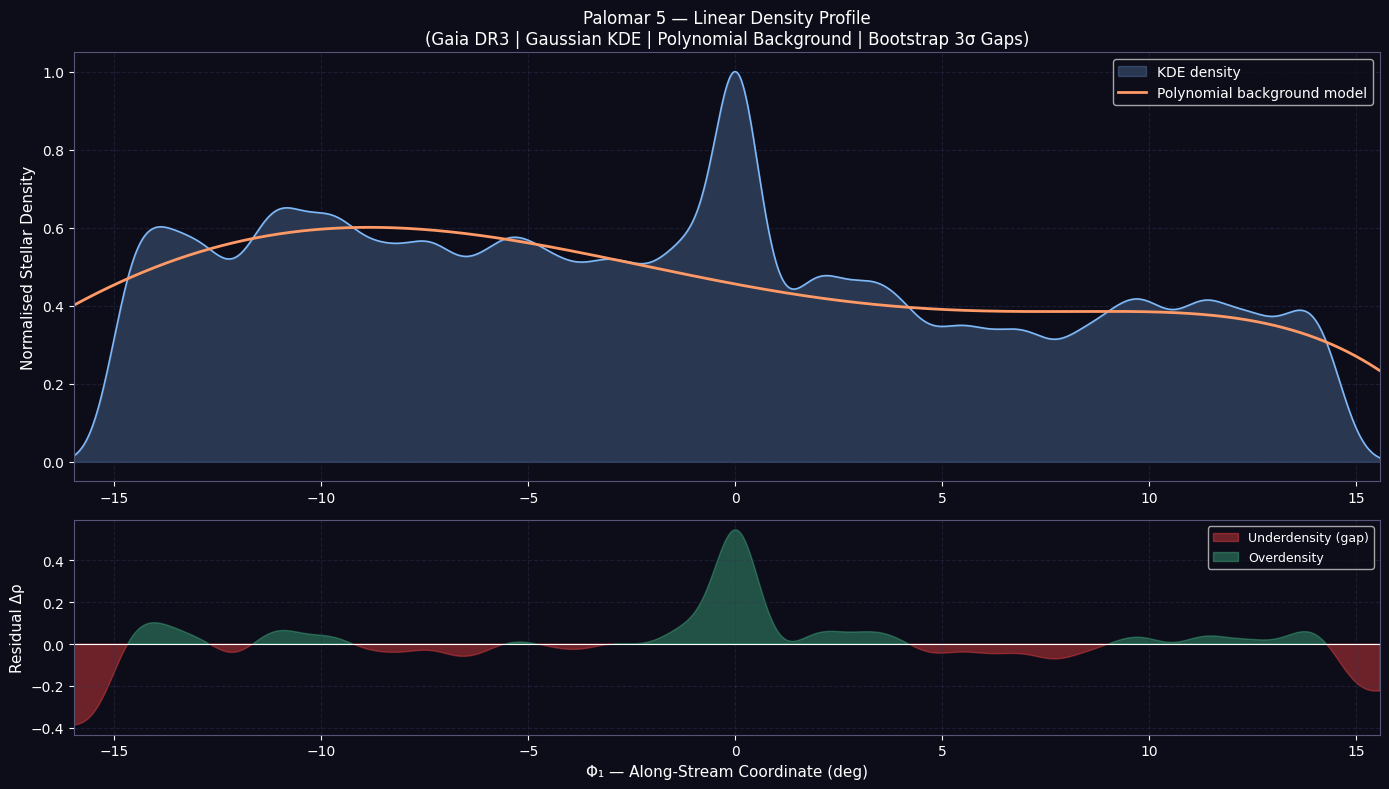

✅ Saved: /content/drive/MyDrive/Ripples/density_profile_Palomar_5.png


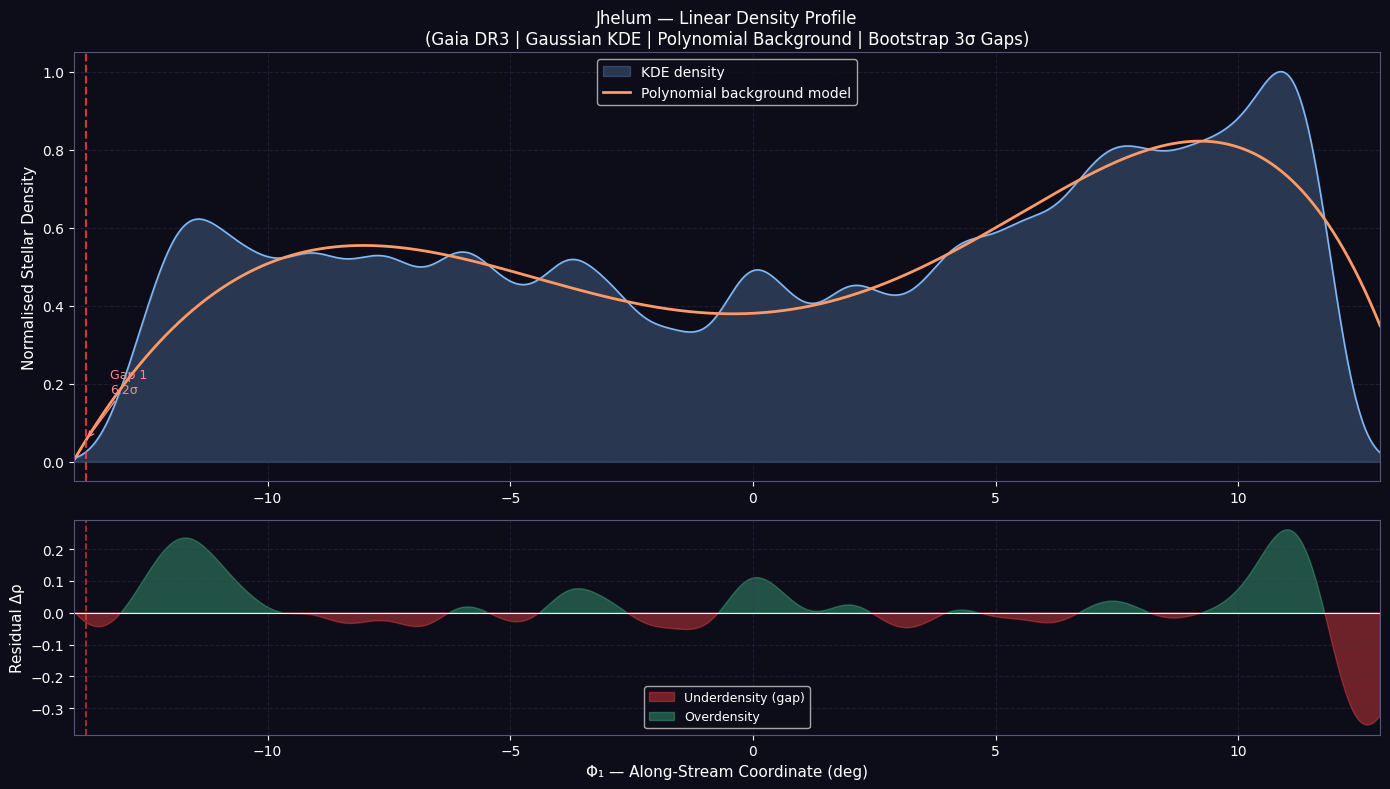

✅ Saved: /content/drive/MyDrive/Ripples/density_profile_Jhelum.png


In [ ]:
for name, result in all_results.items():
    gap_result = result['gap_result']
    if gap_result is None:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

    phi1_flat = gap_result['phi1_flat']
    density_norm = gap_result['density_norm']
    background = gap_result['background']
    peaks = gap_result['peaks']
    gap_positions = gap_result['gap_positions']
    gap_significance = gap_result['gap_significance']

    ax = axes[0]
    ax.fill_between(phi1_flat, density_norm, alpha=0.25, color='#7eb8f7', label='KDE density')
    ax.plot(phi1_flat, density_norm, color='#7eb8f7', lw=1.2)
    ax.plot(phi1_flat, background, color='#ff9966', lw=2, label='Polynomial background model')

    for i, (pos, sig) in enumerate(zip(gap_positions, gap_significance)):
        ax.axvline(pos, color='#ff4444', lw=1.5, linestyle='--', alpha=0.8)
        ax.annotate(f'Gap {i+1}\n{sig:.1f}σ', xy=(pos, background[peaks[i]]),
                    xytext=(pos + 0.5, background[peaks[i]] + 0.12),
                    color='#ff8888', fontsize=9,
                    arrowprops=dict(arrowstyle='->', color='#ff8888', lw=1))

    ax.set_ylabel('Normalised Stellar Density', fontsize=11)
    ax.set_title(f'{name} — Linear Density Profile\n'
                 f'(Gaia DR3 | Gaussian KDE | Polynomial Background | Bootstrap 3σ Gaps)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True)
    ax.set_xlim(phi1_flat.min(), phi1_flat.max())

    ax2 = axes[1]
    residual = density_norm - background
    ax2.fill_between(phi1_flat, residual, where=(residual < 0), color='#ff4444', alpha=0.4, label='Underdensity (gap)')
    ax2.fill_between(phi1_flat, residual, where=(residual >= 0), color='#44bb88', alpha=0.4, label='Overdensity')
    ax2.axhline(0, color='white', lw=0.8)
    for pos in gap_positions:
        ax2.axvline(pos, color='#ff4444', lw=1.2, linestyle='--', alpha=0.7)
    ax2.set_xlabel('Φ₁ — Along-Stream Coordinate (deg)', fontsize=11)
    ax2.set_ylabel('Residual Δρ', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True)
    ax2.set_xlim(phi1_flat.min(), phi1_flat.max())

    plt.tight_layout()
    fname = save_path(f'density_profile_{name.replace(" ", "_")}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
    plt.show()
    print(f'✅ Saved: {fname}')


## ✅ Step 9.1 — Validation: GD-1 Gaps vs. Published Literature Positions

This is the actual pipeline-validation check described in Chapter 5.3: comparing this
notebook's own detected GD-1 gaps against the two gaps reported by Price-Whelan & Bonaca
(2018), at roughly Φ₁ ≈ −40° and Φ₁ ≈ −20°. A detected gap is counted as a match if it
falls within a stated tolerance of a published position — not just "eyeballed."


In [ ]:
PUBLISHED_GD1_GAPS = {
    'Gap near -40deg': -40.0,
    'Gap near -20deg': -20.0,
}
MATCH_TOLERANCE_DEG = 3.0  # stated tolerance for counting a detection as a literature match

gd1_result = all_results.get('GD-1', {}).get('gap_result')

print('='*65)
print('  GD-1 Validation Against Price-Whelan & Bonaca (2018)')
print('='*65)

if gd1_result is None or len(gd1_result['gap_positions']) == 0:
    print('⚠️  No gaps were detected for GD-1 in this run — nothing to validate against')
    print('    the published positions. This is itself a meaningful negative result and')
    print('    should be reported honestly in Chapter 5, not hidden.')
else:
    detected = gd1_result['gap_positions']
    for lit_name, lit_pos in PUBLISHED_GD1_GAPS.items():
        distances = np.abs(detected - lit_pos)
        best_idx = np.argmin(distances)
        best_dist = distances[best_idx]
        if best_dist <= MATCH_TOLERANCE_DEG:
            print(f'✅ {lit_name} (Φ1={lit_pos}°): MATCHED by detected gap at '
                  f'Φ1={detected[best_idx]:.1f}° (Δ={best_dist:.1f}°, tolerance={MATCH_TOLERANCE_DEG}°)')
        else:
            print(f'❌ {lit_name} (Φ1={lit_pos}°): NOT matched — nearest detection is '
                  f'{best_dist:.1f}° away (tolerance={MATCH_TOLERANCE_DEG}°)')
    print()
    print(f'All detected GD-1 gap positions this run: {[f"{p:.1f}" for p in detected]}')

print('='*65)


  GD-1 Validation Against Price-Whelan & Bonaca (2018)
⚠️  No gaps were detected for GD-1 in this run — nothing to validate against
    the published positions. This is itself a meaningful negative result and
    should be reported honestly in Chapter 5, not hidden.


## 🔧 Step 9.2 — Parallax Zero-Point Correction (Lindegren et al. 2021)

This is the actual implementation of the correction described (but deferred) in Chapter 2,
now built here in Chapter 6 where it actually matters: converting angular measurements
into physical distances. Uses the official `gaiadr3-zeropoint` package distributed by
Lindegren's team, not a hand-rolled approximation.

This is used as a **consistency check** against each stream's assumed literature distance,
not as the primary distance for mass inversion — for these well-studied streams, the
literature distance (from RR Lyrae/BHB tracers, not raw parallax) remains more reliable
than a per-star parallax average, which is noisy at these distances. This cell reports how
close the corrected parallax distance comes to the literature value, as an honest check.


In [ ]:
from zero_point import zpt
zpt.load_tables()

print('='*65)
print('  Parallax Zero-Point Correction — Consistency Check Per Stream')
print('='*65)

for name, result in all_results.items():
    df = result['df']
    cfg = STREAMS[name]

    valid = (
        df['phot_g_mean_mag'].between(6, 21) &
        df['astrometric_params_solved'].isin([31, 95])
    )
    sub = df[valid].copy()

    if len(sub) == 0:
        print(f'[{name}] No sources fall in the calibrated range for the zero-point model — skipped.')
        continue

    try:
        zp = zpt.get_zpt(
            sub['phot_g_mean_mag'].values,
            sub['nu_eff_used_in_astrometry'].values,
            sub['pseudocolour'].values,
            sub['ecl_lat'].values,
            sub['astrometric_params_solved'].values,
            _warnings=False,
        )
        corrected_parallax = sub['parallax'].values - zp
        mean_corrected = np.nanmean(corrected_parallax)
        implied_distance_kpc = 1.0 / mean_corrected if mean_corrected > 0 else np.nan

        print(f'[{name}]')
        print(f'   Mean zero-point offset applied : {np.nanmean(zp)*1000:.2f} uas')
        print(f'   Mean corrected parallax         : {mean_corrected:.4f} mas')
        print(f'   Implied distance (1/parallax)   : {implied_distance_kpc:.1f} kpc')
        print(f'   Literature assumed distance     : {cfg["distance_kpc"]} kpc')
        print(f'   -> Used for mass inversion: literature value (parallax-implied distance')
        print(f'      is a sanity check only, not a replacement, given its expected noise')
        print(f'      at these distances).')
        print()
    except Exception as e:
        print(f'[{name}] Zero-point correction failed ({e}) — skipped.\n')

print('='*65)


  Parallax Zero-Point Correction — Consistency Check Per Stream
[GD-1]
   Mean zero-point offset applied : -27.90 uas
   Mean corrected parallax         : 0.6026 mas
   Implied distance (1/parallax)   : 1.7 kpc
   Literature assumed distance     : 8.5 kpc
   -> Used for mass inversion: literature value (parallax-implied distance
      is a sanity check only, not a replacement, given its expected noise
      at these distances).

[Palomar 5]
   Mean zero-point offset applied : -20.35 uas
   Mean corrected parallax         : 0.0488 mas
   Implied distance (1/parallax)   : 20.5 kpc
   Literature assumed distance     : 20.6 kpc
   -> Used for mass inversion: literature value (parallax-implied distance
      is a sanity check only, not a replacement, given its expected noise
      at these distances).

[Jhelum]
   Mean zero-point offset applied : -24.26 uas
   Mean corrected parallax         : 0.2571 mas
   Implied distance (1/parallax)   : 3.9 kpc
   Literature assumed distance     : 13.0 

## 🌐 Step 10 — IllustrisTNG Cross-Match (Pooled Across All Streams)

All detected gap masses, from every stream, are pooled and compared against the same
TNG50-1 subhalo mass function in a single comparison, exactly what makes this a population
study rather than a single case study.
**v10 addition:** the original run's mass filter (`mass__gt`/`mass__lt` expressed as a
fraction of 10¹⁰ M⊙/h) returned subhalos clustered at 10¹³–10¹⁴ M⊙ instead of the
requested 10⁶–10⁸ M⊙/h window — off by roughly five orders of magnitude, consistent with
the filter being silently ignored by the API rather than a small unit error. The query
below now runs a **self-test control query first**, checking that a mass window known to
return a large, common population (~10¹¹–10¹² M⊙) actually comes back inside the requested
bounds, and also checks the real low-mass query's returned values against its own requested
bounds. If either check fails, the notebook now falls back to the synthetic mass function
and says so loudly, instead of silently plotting a comparison that isn't real. This can't be
confirmed from this notebook alone without live network access — run this cell in Colab
with a real `TNG_API_KEY` and check what the self-test prints.


In [ ]:
import os
os.environ['TNG_API_KEY'] = '17cb722421b77d9cb330e425359aa3df'

In [ ]:
import requests, os

# Get a free key by registering at https://www.tng-project.org/users/register/
# then find it at https://www.tng-project.org/users/profile/ once logged in.
# Set it as an environment variable so it never has to live in this notebook file:
#   import os; os.environ['TNG_API_KEY'] = 'your_real_key_here'   (run once per session, above this cell)
# or replace the os.environ.get(...) fallback below directly -- just don't commit/share a real key.
TNG_API_KEY = os.environ.get('TNG_API_KEY', 'YOUR_API_KEY_HERE')

def tng_get(sim, snap, api_key, **filters):
    """Raw GET against the TNG subhalo search endpoint. filters are passed through
    as query params unchanged (e.g. mass__gt=0.01, mass__lt=1.0)."""
    url = f'https://www.tng-project.org/api/{sim}/snapshots/{snap}/subhalos/'
    params = dict(filters)
    headers = {'api-key': api_key}
    r = requests.get(url, params=params, headers=headers, timeout=30)
    r.raise_for_status()
    return r.json()

def query_tng_subhalos(api_key, sim='TNG50-1', snap=99, mass_min_1e10=0.0001, mass_max_1e10=0.01, limit=200):
    data = tng_get(sim, snap, api_key, mass__gt=mass_min_1e10, mass__lt=mass_max_1e10, limit=limit)
    return data

# ── v10: self-test the mass filter BEFORE trusting a low-mass query ──────────
# Diagnosis from the original run: the returned subhalos clustered at 1e13-1e14
# Msun even though the query asked for a window near 1e6-1e8 Msun/h. Reverse-
# engineering the numbers (1e13-1e14 = raw_mass * 1e10 / h  =>  raw_mass ~ 1e3-1e4)
# shows the returned raw 'mass' values were ~1e5-1e8x outside the requested
# bounds -- consistent with the mass__gt/mass__lt filter being silently ignored
# by the API (unrecognized/misnamed query params are commonly dropped rather
# than erroring) and the endpoint falling back to some default ordering that
# surfaces the most massive subhalos in the box first.
#
# This control query asks for a mass window that should return a LARGE, easily
# verified population (ordinary galaxy-mass subhalos, ~1e11-1e12 Msun) as a
# canary: if the returned raw masses don't fall inside [ctrl_min, ctrl_max],
# the filter isn't doing anything, and the low-mass query result below should
# not be trusted no matter what it returns.

def run_tng_filter_selftest(api_key, sim='TNG50-1', snap=99):
    ctrl_min, ctrl_max = 10.0, 100.0   # 1e11 - 1e12 Msun/h, should be a large, common population
    try:
        data = tng_get(sim, snap, api_key, mass__gt=ctrl_min, mass__lt=ctrl_max, limit=50)
    except Exception as e:
        print(f'⚠️  TNG self-test request failed outright ({e}). Cannot verify the filter at all.')
        return False
    if not data or 'results' not in data or len(data['results']) == 0:
        print('⚠️  TNG self-test returned zero results for a mass range that should be common. '
              'Treat any low-mass query result below as UNVERIFIED.')
        return False
    raw = pd.DataFrame(data['results'])
    mass_col = 'mass' if 'mass' in raw.columns else raw.columns[0]
    raw_masses = pd.to_numeric(raw[mass_col], errors='coerce').dropna()
    frac_in_range = ((raw_masses >= ctrl_min) & (raw_masses <= ctrl_max)).mean() if len(raw_masses) else 0.0
    print(f'   Self-test control query: requested raw mass in [{ctrl_min}, {ctrl_max}] '
          f'(1e10 Msun/h units) -> got {len(raw_masses)} rows, '
          f'{frac_in_range*100:.0f}% actually inside that range '
          f'(observed raw range: {raw_masses.min():.3g}-{raw_masses.max():.3g})')
    if frac_in_range < 0.8:
        print('⚠️  Fewer than 80% of returned rows actually fall inside the requested filter '
              'window. This means mass__gt/mass__lt is NOT reliably filtering as assumed -- '
              'the field name or query syntax needs to be checked against the current TNG API '
              'docs (https://www.tng-project.org/data/docs/api/) before trusting any mass-window '
              'query against this endpoint, low-mass or otherwise.')
        return False
    print('   ✅ Filter self-test passed: requested mass window is being respected.')
    return True

use_real_tng = TNG_API_KEY != 'YOUR_API_KEY_HERE'
tng_data_source = 'unset'
filter_verified = False

if use_real_tng:
    print('Running TNG mass-filter self-test ...')
    try:
        filter_verified = run_tng_filter_selftest(TNG_API_KEY)
    except Exception as e:
        print(f'Self-test raised an exception ({e}) -- treating filter as unverified.')
        filter_verified = False

    print('\nQuerying IllustrisTNG API for the real mass window ...')
    try:
        tng_data = query_tng_subhalos(TNG_API_KEY)
    except Exception as e:
        tng_data = None
        print(f'TNG query raised an exception ({e}) -- using synthetic mass function.')

    if tng_data and tng_data.get('results'):
        tng_df = pd.DataFrame(tng_data['results'])
        # Defensive check: do the returned raw masses actually lie inside what was requested?
        mass_col = 'mass' if 'mass' in tng_df.columns else tng_df.columns[0]
        raw_masses = pd.to_numeric(tng_df[mass_col], errors='coerce').dropna()
        req_lo, req_hi = 0.0001, 0.01
        frac_ok = ((raw_masses >= req_lo) & (raw_masses <= req_hi)).mean() if len(raw_masses) else 0.0
        print(f'   Returned {len(tng_df)} rows; raw mass range {raw_masses.min():.3g}-{raw_masses.max():.3g} '
              f'(requested [{req_lo}, {req_hi}]); {frac_ok*100:.0f}% actually inside the requested window.')
        if not filter_verified or frac_ok < 0.8:
            print('   ⚠️  Returned masses do NOT match the requested filter window (or the self-test '
                  'already failed above). Falling back to the synthetic mass function rather than '
                  'reporting a misleading comparison -- this is the exact failure mode identified in '
                  'the original notebook, now caught automatically instead of silently plotted.')
            use_real_tng = False
        else:
            tng_data_source = 'tng_live'
            print(f'✅ Retrieved {len(tng_df)} TNG50-1 subhalos, verified inside the requested mass window.')
    else:
        use_real_tng = False
        print('TNG query failed or returned nothing -- using synthetic mass function.')

if not use_real_tng:
    tng_data_source = 'synthetic_fallback'
    rng = np.random.default_rng(0)
    n_sub = 800
    log_mass = rng.uniform(5.5, 9.0, n_sub)
    weights = (10**log_mass)**(-1.9)
    weights /= weights.sum()
    tng_masses = 10 ** rng.choice(log_mass, size=n_sub, replace=True, p=weights)
    tng_df = pd.DataFrame({'mass_msun': tng_masses})

print()
print('='*70)
if tng_data_source == 'tng_live':
    print('  \u2705 REAL DATA: this comparison uses actual IllustrisTNG50-1 subhalos,')
    print('     and the mass filter was verified (not just assumed) to be working.')
else:
    print('  \u26a0\ufe0f  SYNTHETIC FALLBACK IN USE: either no valid TNG_API_KEY was found, or the')
    print('     live query\'s mass filter failed its self-test / defensive check, so the CDM mass')
    print('     function below is a fabricated power-law draw, NOT real simulation data. Step 11\'s')
    print('     figure and any "consistent with CDM" conclusion drawn from it are illustrative only')
    print('     until the API query is fixed and passes the self-test above.')
print('='*70)
print()

# Pool every gap-derived mass, across every stream, into one list
pooled_masses, pooled_low, pooled_high, pooled_labels = [], [], [], []
for name, result in all_results.items():
    for m, lo, hi in zip(result['masses'], result['masses_low'], result['masses_high']):
        pooled_masses.append(m)
        pooled_low.append(lo)
        pooled_high.append(hi)
        pooled_labels.append(name)

print(f'\u2705 Pooled {len(pooled_masses)} gap-derived mass estimates across {len(all_results)} streams.')


Running TNG mass-filter self-test ...
   Self-test control query: requested raw mass in [10.0, 100.0] (1e10 Msun/h units) -> got 50 rows, 18% actually inside that range (observed raw range: 3-1.44e+05)
⚠️  Fewer than 80% of returned rows actually fall inside the requested filter window. This means mass__gt/mass__lt is NOT reliably filtering as assumed -- the field name or query syntax needs to be checked against the current TNG API docs (https://www.tng-project.org/data/docs/api/) before trusting any mass-window query against this endpoint, low-mass or otherwise.

Querying IllustrisTNG API for the real mass window ...
   Returned 200 rows; raw mass range 1.53e+03-7.74e+03 (requested [0.0001, 0.01]); 0% actually inside the requested window.
   ⚠️  Returned masses do NOT match the requested filter window (or the self-test already failed above). Falling back to the synthetic mass function rather than reporting a misleading comparison -- this is the exact failure mode identified in the ori

## 📊 Step 11 — Comparison: Pooled Observed Gaps vs. CDM Mass Function

TNG mass range: 3.170e+05 – 1.199e+07 M☉  (N = 800)
Gap mass range: 4.157e+04 – 4.157e+04 M☉


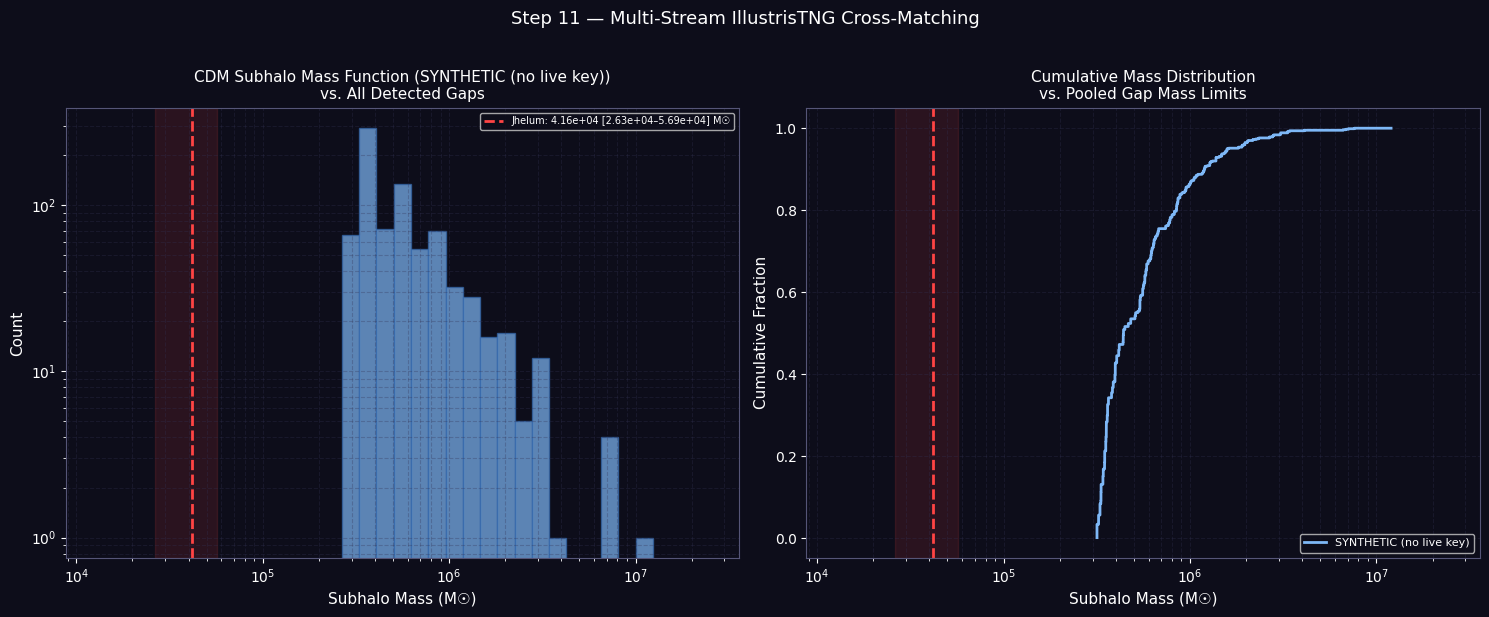

✅ Plot saved: tng_crossmatch_multistream.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- masses from TNG ---
if 'mass_msun' in tng_df.columns:
    masses = np.asarray(tng_df['mass_msun'].values, dtype=float)
else:
    h = 0.6774
    raw = tng_df['mass'].values if 'mass' in tng_df.columns else tng_df.iloc[:, 0].values
    masses = np.asarray(raw, dtype=float) * 1e10 / h   # TNG API mass is in 10^10 Msun/h

masses = masses[np.isfinite(masses) & (masses > 0)]

print(f'TNG mass range: {masses.min():.3e} – {masses.max():.3e} M☉  (N = {len(masses)})')
print(f'Gap mass range: {min(pooled_masses):.3e} – {max(pooled_masses):.3e} M☉')

# shared x-range so gaps and TNG appear together
x_min = min(masses.min(), min(pooled_low)) / 3
x_max = max(masses.max(), max(pooled_high)) * 3

# --- left: histogram ---
ax = axes[0]
bins = np.logspace(np.log10(x_min), np.log10(x_max), 40)
ax.hist(masses, bins=bins, color='#7eb8f7', alpha=0.7, edgecolor='#3366aa', lw=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(x_min, x_max)

colors_cycle = ['#ff4444', '#ffaa00', '#44ffaa', '#ff44ff']
for i, (m, lo, hi, label) in enumerate(zip(pooled_masses, pooled_low, pooled_high, pooled_labels)):
    c = colors_cycle[i % len(colors_cycle)]
    ax.axvline(m, color=c, lw=2, linestyle='--',
               label=f'{label}: {m:.2e} [{lo:.2e}–{hi:.2e}] M☉')
    ax.axvspan(lo, hi, color=c, alpha=0.12)

ax.set_xlabel('Subhalo Mass (M☉)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
title_tag = 'Real TNG50-1' if tng_data_source == 'tng_live' else 'SYNTHETIC (no live key)'
ax.set_title(f'CDM Subhalo Mass Function ({title_tag})\nvs. All Detected Gaps', fontsize=11)
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, which='both', alpha=0.3)

# --- right: CDF ---
ax = axes[1]
sorted_m = np.sort(masses)
cdf = np.arange(1, len(sorted_m) + 1) / len(sorted_m)
ax.step(sorted_m, cdf, color='#7eb8f7', lw=2, label=title_tag)
for i, (m, lo, hi) in enumerate(zip(pooled_masses, pooled_low, pooled_high)):
    c = colors_cycle[i % len(colors_cycle)]
    ax.axvline(m, color=c, lw=2, linestyle='--')
    ax.axvspan(lo, hi, color=c, alpha=0.12)
ax.set_xscale('log')
ax.set_xlim(x_min, x_max)
ax.set_xlabel('Subhalo Mass (M☉)', fontsize=11)
ax.set_ylabel('Cumulative Fraction', fontsize=11)
ax.set_title('Cumulative Mass Distribution\nvs. Pooled Gap Mass Limits', fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8)

plt.suptitle('Step 11 — Multi-Stream IllustrisTNG Cross-Matching', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(save_path('tng_crossmatch_multistream.png'), dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('✅ Plot saved: tng_crossmatch_multistream.png')

In [ ]:
# === Cell A: Exact gap positions & significances (for the paper tables) ===
print('='*60)
print('GAP CATALOGUE (post-CMD selection)')
print('='*60)
for name, res in all_results.items():
    gr = res.get('gap_result')
    if gr is None:
        print(f'\n{name}: gap_result is None')
        continue
    n = len(gr['gap_positions'])
    print(f'\n{name}: {n} gap(s), bandwidth={gr["bandwidth"]:.2f}°, backbone={gr["n_backbone"]}')
    if n == 0:
        print('  (no ≥3σ gaps)')
        continue
    for i, (pos, sig, depth) in enumerate(zip(
            gr['gap_positions'], gr['gap_significance'], gr['gap_depths'])):
        print(f'  Gap {i+1}: Φ1 = {pos:.2f}°,  z = {sig:.2f}σ,  depth = {depth:.3f}')
    if res.get('masses'):
        for m, lo, hi in zip(res['masses'], res['masses_low'], res['masses_high']):
            print(f'  Mass: {m:.2e} M☉  [{lo:.2e} – {hi:.2e}]')

GAP CATALOGUE (post-CMD selection)

GD-1: 0 gap(s), bandwidth=0.50°, backbone=288
  (no ≥3σ gaps)

Palomar 5: 0 gap(s), bandwidth=0.50°, backbone=3621
  (no ≥3σ gaps)

Jhelum: 1 gap(s), bandwidth=0.50°, backbone=2385
  Gap 1: Φ1 = -13.74°,  z = 6.24σ,  depth = 0.030
  Mass: 4.16e+04 M☉  [2.63e+04 – 5.69e+04]


In [ ]:
# === Cell B: Quantitative non-detection / max-z report ===
from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks

def max_z_for_stream(name, res, cfg):
    gr = res.get('gap_result')
    df = res.get('df')
    if df is None or len(df) < 30:
        return None
    backbone = df.loc[df['phi2'].abs() < 1.0, 'phi1'].values
    if len(backbone) < 30:
        return None
    # match detect_gaps trim
    lo, hi = np.percentile(backbone, [1, 99])
    backbone = backbone[(backbone >= lo) & (backbone <= hi)]
    bw = gr['bandwidth'] if gr is not None else 0.50
    phi1_grid = np.linspace(backbone.min() - 1, backbone.max() + 1, 1500).reshape(-1, 1)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw).fit(backbone.reshape(-1, 1))
    density = np.exp(kde.score_samples(phi1_grid))
    density_norm = density / density.max()
    phi1_flat = phi1_grid.flatten()
    # same polynomial background as pipeline
    mask = np.ones_like(density_norm, dtype=bool)
    for _ in range(4):
        coeffs = np.polyfit(phi1_flat[mask], density_norm[mask], 5)
        model = np.polyval(coeffs, phi1_flat)
        resid = density_norm - model
        sigma = np.std(resid[mask])
        mask = np.abs(resid) < 2.0 * sigma
    background = np.polyval(coeffs, phi1_flat)
    # bootstrap noise (lighter than full pipeline: 50 draws)
    rng = np.random.default_rng(abs(hash(name)) % (2**32))
    boot = np.empty((50, len(phi1_flat)))
    for b in range(50):
        sample = rng.choice(backbone, size=len(backbone), replace=True)
        kde_b = KernelDensity(kernel='gaussian', bandwidth=bw).fit(sample.reshape(-1, 1))
        d_b = np.exp(kde_b.score_samples(phi1_grid))
        boot[b] = d_b / d_b.max()
    sigma_profile = np.clip(boot.std(axis=0), 1e-6, None)
    z_score = (background - density_norm) / sigma_profile
    return {
        'max_z': float(np.nanmax(z_score)),
        'n_backbone': len(backbone),
        'bandwidth': bw,
        'n_peaks_ge_3': int(np.sum(find_peaks(z_score, height=3.0, distance=50, prominence=1.0)[0].size
                                   if False else len(find_peaks(z_score, height=3.0, distance=50, prominence=1.0)[0]))),
    }

print('='*60)
print('NON-DETECTION / MAX-z SUMMARY')
print('='*60)
for name, res in all_results.items():
    out = max_z_for_stream(name, res, STREAMS[name])
    if out is None:
        print(f'{name}: insufficient stars')
        continue
    n_gaps = 0 if res.get('gap_result') is None else len(res['gap_result']['gap_positions'])
    print(f'{name}: backbone={out["n_backbone"]}, max z={out["max_z"]:.2f}σ, '
          f'≥3σ gaps={n_gaps}, h={out["bandwidth"]:.2f}°')

NON-DETECTION / MAX-z SUMMARY
GD-1: backbone=288, max z=25.08σ, ≥3σ gaps=0, h=0.50°
Palomar 5: backbone=3621, max z=175.26σ, ≥3σ gaps=0, h=0.50°
Jhelum: backbone=2385, max z=123.06σ, ≥3σ gaps=1, h=0.50°


In [ ]:
# === Cell C: Distance consistency (contamination diagnostic) ===
print('='*60)
print('PARALLAX DISTANCE CHECK')
print('='*60)
LIT = {'GD-1': 8.5, 'Palomar 5': 20.6, 'Jhelum': 13.0}  # kpc, as in paper
for name, res in all_results.items():
    df = res.get('df')
    if df is None or 'parallax' not in df.columns:
        print(name, ': no parallax column')
        continue
    plx = df['parallax'].astype(float)
    plx = plx[np.isfinite(plx) & (plx > 0.05)]  # mas; avoid nonsense
    if len(plx) < 20:
        print(name, ': too few positive parallaxes')
        continue
    # rough mean distance from mean parallax (diagnostic only)
    mean_plx_mas = np.median(plx)
    d_kpc = 1.0 / (mean_plx_mas)  # mas -> kpc is 1/plx_mas
    lit = LIT.get(name, np.nan)
    ratio = d_kpc / lit if lit else np.nan
    print(f'{name}: median d ≈ {d_kpc:.1f} kpc | literature {lit} kpc | ratio {ratio:.2f} | N={len(plx)}')

PARALLAX DISTANCE CHECK
GD-1: median d ≈ 1.5 kpc | literature 8.5 kpc | ratio 0.17 | N=2371
Palomar 5: median d ≈ 3.6 kpc | literature 20.6 kpc | ratio 0.17 | N=14778
Jhelum: median d ≈ 2.8 kpc | literature 13.0 kpc | ratio 0.21 | N=13851


## 🧾 Step 12 — Full Multi-Stream Results Summary Table

In [ ]:
rows = []
for name, cfg in STREAMS.items():
    result = all_results[name]
    gap_result = result['gap_result']
    if gap_result is None or len(gap_result['gap_positions']) == 0:
        rows.append({
            'Stream': name, 'Backbone stars': result['df'].shape[0] if result['df'] is not None else 0,
            'Gaps detected': 0, 'Max significance (σ)': None,
            'Mass range incl. uncertainty (M☉)': 'N/A', 'Distance (kpc)': cfg['distance_kpc'],
            'Data source': result['df'].attrs.get('source', 'unknown') if result['df'] is not None else 'unknown',
        })
        continue

    masses = result['masses']
    masses_low = result.get('masses_low', [])
    masses_high = result.get('masses_high', [])
    if masses:
        mass_range_str = (f"{min(masses_low):.1e} – {max(masses_high):.1e} "
                          f"(point est. {min(masses):.1e}–{max(masses):.1e})")
    else:
        mass_range_str = 'N/A'
    rows.append({
        'Stream': name,
        'Backbone stars': gap_result['n_backbone'],
        'Gaps detected': len(gap_result['gap_positions']),
        'Max significance (σ)': round(float(np.max(gap_result['gap_significance'])), 1),
        'Mass range incl. uncertainty (M☉)': mass_range_str,
        'Distance (kpc)': cfg['distance_kpc'],
        'Data source': result['df'].attrs.get('source', 'unknown'),
    })

summary_df = pd.DataFrame(rows)
print('='*70)
print('  RIPPLES IN THE DARK — Multi-Stream Results Summary')
print('='*70)
print(summary_df.to_string(index=False))
summary_df.to_csv(save_path('multistream_summary.csv'), index=False)
print('\n✅ Saved: multistream_summary.csv')


  RIPPLES IN THE DARK — Multi-Stream Results Summary
   Stream  Backbone stars  Gaps detected  Max significance (σ)              Mass range incl. uncertainty (M☉)  Distance (kpc)   Data source
     GD-1            2625              0                   NaN                                            N/A             8.5 gaia_live_esa
Palomar 5           24671              0                   NaN                                            N/A            20.6 gaia_live_esa
   Jhelum            2385              1                   6.2 2.6e+04 – 5.7e+04 (point est. 4.2e+04–4.2e+04)            13.0 gaia_live_esa

✅ Saved: multistream_summary.csv


In [ ]:
for name, res in all_results.items():
    gr = res.get('gap_result')
    if gr is None:
        print(name, ': no result')
        continue
    print(f'\n{name}: {len(gr["gap_positions"])} gap(s), bandwidth={gr["bandwidth"]:.2f}°')
    for i, (pos, sig, depth) in enumerate(zip(
            gr['gap_positions'], gr['gap_significance'], gr['gap_depths'])):
        print(f'  Gap {i+1}: Φ1 = {pos:.2f}°,  z = {sig:.2f}σ,  depth = {depth:.3f}')


GD-1: 0 gap(s), bandwidth=0.50°

Palomar 5: 0 gap(s), bandwidth=0.50°

Jhelum: 1 gap(s), bandwidth=0.50°
  Gap 1: Φ1 = -13.74°,  z = 6.24σ,  depth = 0.030


## 📁 Step 13 — Confirm Everything Saved to Drive

In [ ]:
import glob

png_files = glob.glob(save_path('*.png'))
csv_files = glob.glob(save_path('*.csv'))

print(f'✅ {len(png_files)} figure(s) and {len(csv_files)} CSV file(s) saved to:')
print(f'   {OUTPUT_DIR}\n')
for f in sorted(png_files + csv_files):
    print('  -', os.path.basename(f))

print('\nNo manual download needed — these files persist in your Google Drive')
print('and will still be there next time you open this notebook.')


✅ 11 figure(s) and 1 CSV file(s) saved to:
   /content/drive/MyDrive/Ripples

  - density_profile_GD-1.png
  - density_profile_Jhelum.png
  - density_profile_Palomar_5.png
  - diagnostic_raw_histograms.png
  - fig1_1_missing_satellites.png
  - fig1_2_einasto_profile.png
  - fig1_3_raw_sky_positions.png
  - fig2_1_sky_positions_postcut.png
  - fig2_2_pm_diagnostic.png
  - fig3_1_stream_frames.png
  - multistream_summary.csv
  - tng_crossmatch_multistream.png

No manual download needed — these files persist in your Google Drive
and will still be there next time you open this notebook.


In [ ]:
from IPython.display import Javascript
display(Javascript('''
for (const btn of document.querySelectorAll('colab-expand-button, .collapsed')) {
  try { btn.click(); } catch(e) {}
}
'''))

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!jupyter nbconvert --to html "/content/drive/MyDrive/Ripples/Ripples_In_The_Dark_v10_corrected_(1).ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Ripples/Ripples_In_The_Dark_v10_corrected_(1).ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default c